In [1]:
import os

base_dir = r"D:\ADNI1_Complete 1Yr 1.5T"

nii_files = []

for root, dirs, files in os.walk(base_dir):
    for file in files:
        if file.endswith(".nii") or file.endswith(".nii.gz"):
            full_path = os.path.join(root, file)
            nii_files.append(full_path)

print(f"Total NIFTI files found: {len(nii_files)}")

Total NIFTI files found: 2294


In [2]:
import pandas as pd

csv_path = r"D:\ADNI1_Complete_1Yr_1.5T_12_20_2024.csv"

df = pd.read_csv(csv_path)

print(df.columns)
df.head()

Index(['Image Data ID', 'Subject', 'Group', 'Sex', 'Age', 'Visit', 'Modality',
       'Description', 'Type', 'Acq Date', 'Format', 'Downloaded'],
      dtype='object')


,Image Data ID,Subject,Group,Sex,Age,Visit,Modality,Description,Type,Acq Date,Format,Downloaded
0,I112538,941_S_1311,MCI,M,70,m12,MRI,MPR; GradWarp; B1 Correction; N3; Scaled,Processed,6/01/2008,NiFTI,12/07/2024
1,I97341,941_S_1311,MCI,M,70,m06,MRI,MPR-R; GradWarp; B1 Correction; N3; Scaled,Processed,9/27/2007,NiFTI,12/07/2024
2,I97327,941_S_1311,MCI,M,69,sc,MRI,MPR; GradWarp; B1 Correction; N3; Scaled,Processed,3/02/2007,NiFTI,12/07/2024
3,I63874,941_S_1202,CN,M,78,sc,MRI,MPR-R; GradWarp; B1 Correction; N3; Scaled,Processed,1/30/2007,NiFTI,12/07/2024
4,I75150,941_S_1202,CN,M,78,m06,MRI,MPR; GradWarp; B1 Correction; N3; Scaled,Processed,8/24/2007,NiFTI,12/07/2024


In [3]:
import pandas as pd

csv_path = r"D:\ADNI1_Complete_1Yr_1.5T_12_20_2024.csv"

df = pd.read_csv(csv_path)

# Keep only needed columns
df = df[['Image Data ID', 'Group']].dropna()

# Convert to string
df['Image Data ID'] = df['Image Data ID'].astype(str)

# Create mapping
label_map = dict(zip(df['Image Data ID'], df['Group']))

print("Total labels:", len(label_map))

Total labels: 2294


In [4]:
import os

base_dir = r"D:\ADNI1_Complete 1Yr 1.5T"

nii_files = []

for root, dirs, files in os.walk(base_dir):
    for file in files:
        if file.endswith(".nii") or file.endswith(".nii.gz"):
            nii_files.append(os.path.join(root, file))

print("Total NIFTI files:", len(nii_files))

Total NIFTI files: 2294


In [5]:
import re

def extract_image_id(filepath):
    filename = os.path.basename(filepath)

    # Look for pattern like I123456
    match = re.search(r'I\d+', filename)

    if match:
        return match.group(0)
    else:
        return None

In [6]:
import os
import pandas as pd
import re

# Load CSV
csv_path = r"D:\ADNI1_Complete_1Yr_1.5T_12_20_2024.csv"
df = pd.read_csv(csv_path)

df = df[['Image Data ID', 'Group']].dropna()
df['Image Data ID'] = df['Image Data ID'].astype(str)

label_map = dict(zip(df['Image Data ID'], df['Group']))

# Scan files
base_dir = r"D:\ADNI1_Complete 1Yr 1.5T"

data = []

def extract_image_id(filepath):
    match = re.search(r'I\d+', filepath)
    return match.group(0) if match else None

for root, _, files in os.walk(base_dir):
    for file in files:
        if file.endswith(".nii") or file.endswith(".nii.gz"):
            full_path = os.path.join(root, file)

            img_id = extract_image_id(file)

            if img_id and img_id in label_map:
                label = label_map[img_id]
                data.append([full_path, label])

# Save mapping
df_paths = pd.DataFrame(data, columns=['filepath', 'label'])
df_paths.to_csv("D:\\ADNI_paths_labels.csv", index=False)

print("Saved mapping file ✅")
print(df_paths['label'].value_counts())

Saved mapping file ✅
label
MCI    1113
CN      705
AD      476
Name: count, dtype: int64


In [52]:
import pandas as pd

df = pd.read_csv(r"D:\ADNI_paths_labels.csv")

print(df.head())
print(df['label'].value_counts())

                                            filepath label
0  D:\ADNI1_Complete 1Yr 1.5T\ADNI\002_S_0295\MPR...    CN
1  D:\ADNI1_Complete 1Yr 1.5T\ADNI\002_S_0295\MPR...    CN
2  D:\ADNI1_Complete 1Yr 1.5T\ADNI\002_S_0295\MPR...    CN
3  D:\ADNI1_Complete 1Yr 1.5T\ADNI\002_S_0295\MPR...    CN
4  D:\ADNI1_Complete 1Yr 1.5T\ADNI\002_S_0295\MPR...    CN
label
MCI    1113
CN      705
AD      476
Name: count, dtype: int64


In [8]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['label'])

print(dict(zip(le.classes_, le.transform(le.classes_))))

{'AD': 0, 'CN': 1, 'MCI': 2}


In [9]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['label'],
    random_state=42
)

train_df, val_df = train_test_split(
    train_df,
    test_size=0.1,
    stratify=train_df['label'],
    random_state=42
)

print(len(train_df), len(val_df), len(test_df))

1651 184 459


In [10]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['label_encoded']),
    y=train_df['label_encoded']
)

class_weights = dict(enumerate(weights))
print(class_weights)

{0: 1.6044703595724004, 1: 1.0854700854700854, 2: 0.6870578443612152}


In [11]:
import pandas as pd

df = pd.read_csv(r"D:\ADNI_paths_labels.csv")

print(df['label'].value_counts())

label
MCI    1113
CN      705
AD      476
Name: count, dtype: int64


In [12]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["label_id"] = le.fit_transform(df["label"])

print(dict(zip(le.classes_, le.transform(le.classes_))))

{'AD': 0, 'CN': 1, 'MCI': 2}


In [13]:
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd,
    ScaleIntensityd, Lambdad, ToTensord
)

d:\Anaconda\envs\py310\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [14]:
transforms = Compose([
    LoadImaged(keys=["image"]),
    EnsureChannelFirstd(keys=["image"]),

    # CORONAL SLICE (middle of width axis)
    Lambdad(keys=["image"], func=lambda x: x[:, :, x.shape[2] // 2]),

    ScaleIntensityd(keys=["image"]),
    ToTensord(keys=["image", "label"])
])

In [15]:
from monai.data import Dataset, DataLoader

data_dicts = [
    {"image": row.filepath, "label": row.label_id}
    for _, row in df.iterrows()
]

dataset = Dataset(data=data_dicts, transform=transforms)
loader = DataLoader(dataset, batch_size=8, shuffle=False)

In [16]:
import torch
from torchvision.models import densenet121

model = densenet121(weights="IMAGENET1K_V1")

# remove classifier head
feature_extractor = model.features

# add pooling to get vector output
feature_extractor.add_module("global_pool", torch.nn.AdaptiveAvgPool2d(1))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

Sequential(
  (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu0): ReLU(inplace=True)
  (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (denseblock1): _DenseBlock(
    (denselayer1): _DenseLayer(
      (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu1): ReLU(inplace=True)
      (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu2): ReLU(inplace=True)
      (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    )
    (denselayer2): _DenseLayer(
      (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu1): ReLU(inplace=True)
      (conv1): Conv2d(96, 128, ke

In [17]:
import numpy as np

features = []
labels = []

with torch.no_grad():
    for batch in loader:
        x = batch["image"].to(device)
        y = batch["label"]

        f = feature_extractor(x)

        # flatten (B, 1024, 1, 1) → (B, 1024)
        f = f.view(f.size(0), -1)

        features.append(f.cpu().numpy())
        labels.append(y.numpy())

X = np.vstack(features)
y = np.concatenate(labels)

print("Feature shape:", X.shape)

RuntimeError: Given groups=1, weight of size [64, 3, 7, 7], expected input[8, 1, 256, 166] to have 3 channels, but got 1 channels instead

In [18]:
from monai.transforms import RepeatChanneld

In [19]:
transforms = Compose([
    LoadImaged(keys=["image"]),
    EnsureChannelFirstd(keys=["image"]),

    # CORONAL SLICE
    Lambdad(keys=["image"], func=lambda x: x[:, :, x.shape[2] // 2]),

    # 🔥 FIX: 1-channel → 3-channel
    RepeatChanneld(keys=["image"], repeats=3),

    ScaleIntensityd(keys=["image"]),
    ToTensord(keys=["image", "label"])
])

In [20]:
import torch
from torchvision.models import densenet121

model = densenet121(weights="IMAGENET1K_V1")

# change input layer to 1 channel MRI
model.features.conv0 = torch.nn.Conv2d(
    1, 64, kernel_size=7, stride=2, padding=3, bias=False
)

# feature extractor
feature_extractor = model.features

# global pooling
feature_extractor.add_module(
    "pool",
    torch.nn.AdaptiveAvgPool2d(1)
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

Sequential(
  (conv0): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu0): ReLU(inplace=True)
  (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (denseblock1): _DenseBlock(
    (denselayer1): _DenseLayer(
      (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu1): ReLU(inplace=True)
      (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu2): ReLU(inplace=True)
      (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    )
    (denselayer2): _DenseLayer(
      (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu1): ReLU(inplace=True)
      (conv1): Conv2d(96, 128, ke

In [21]:
import numpy as np

features = []
labels = []

with torch.no_grad():
    for batch in loader:
        x = batch["image"].to(device)
        y = batch["label"]

        f = feature_extractor(x)

        # flatten (B, 1024, 1, 1) → (B, 1024)
        f = f.view(f.size(0), -1)

        features.append(f.cpu().numpy())
        labels.append(y.numpy())

X = np.vstack(features)
y = np.concatenate(labels)

print("Feature shape:", X.shape)

> collate dict key "image" out of 2 keys
>> collate/stack a list of tensors
>> E: stack expects each tensor to be equal size, but got [1, 256, 166] at entry 0 and [1, 256, 124] at entry 1, shape [torch.Size([1, 256, 166]), torch.Size([1, 256, 124]), torch.Size([1, 256, 166]), torch.Size([1, 256, 166]), torch.Size([1, 256, 166]), torch.Size([1, 256, 166]), torch.Size([1, 256, 166]), torch.Size([1, 256, 166])] in collate([metatensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]]), metatensor([[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         ...,
         [0.0000, 0.0000, 0.0000,  ..., 0.0366, 0.0199, 0.0012],
         [0.0000, 0.0000, 0.000

RuntimeError: stack expects each tensor to be equal size, but got [1, 256, 166] at entry 0 and [1, 256, 124] at entry 1
Collate error on the key 'image' of dictionary data.

MONAI hint: if your transforms intentionally create images of different shapes, creating your `DataLoader` with `collate_fn=pad_list_data_collate` might solve this problem (check its documentation).

In [22]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["label_id"] = le.fit_transform(df["label"])

print(dict(zip(le.classes_, le.transform(le.classes_))))

{'AD': 0, 'CN': 1, 'MCI': 2}


In [23]:
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd,
    ScaleIntensityd, Lambdad, Resize, ToTensord
)

In [24]:
def get_slices(x):
    axial = x[:, :, x.shape[2] // 2]
    coronal = x[:, x.shape[1] // 2, :]
    sagittal = x[x.shape[0] // 2, :, :]
    return axial, coronal, sagittal

In [25]:
base_transform = Compose([
    LoadImaged(keys=["image"]),
    EnsureChannelFirstd(keys=["image"]),
    ScaleIntensityd(keys=["image"]),
])

In [26]:
from monai.data import Dataset, DataLoader

data_dicts = [
    {"image": row.filepath, "label": row.label_id}
    for _, row in df.iterrows()
]

dataset = Dataset(data_dicts, transform=base_transform)
loader = DataLoader(dataset, batch_size=1, shuffle=False)

In [27]:
import torch
from torchvision.models import densenet121

model = densenet121(weights="IMAGENET1K_V1")

feature_extractor = model.features
feature_extractor.add_module(
    "pool",
    torch.nn.AdaptiveAvgPool2d(1)
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

Sequential(
  (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu0): ReLU(inplace=True)
  (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (denseblock1): _DenseBlock(
    (denselayer1): _DenseLayer(
      (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu1): ReLU(inplace=True)
      (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu2): ReLU(inplace=True)
      (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    )
    (denselayer2): _DenseLayer(
      (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu1): ReLU(inplace=True)
      (conv1): Conv2d(96, 128, ke

In [28]:
import numpy as np
import torch.nn.functional as F

X = []
y = []

with torch.no_grad():
    for batch in loader:
        img = batch["image"].to(device)
        label = batch["label"].item()

        img = img.squeeze(0)  # remove batch dim

        # extract slices
        axial = img[:, :, img.shape[2] // 2]
        coronal = img[:, img.shape[1] // 2, :]
        sagittal = img[img.shape[0] // 2, :, :]

        slices = [axial, coronal, sagittal]

        subject_features = []

        for sl in slices:
            sl = sl.unsqueeze(0).unsqueeze(0)  # (1,1,H,W)
            sl = F.interpolate(sl, size=(224, 224), mode="bilinear")

            feat = feature_extractor(sl)
            feat = feat.view(feat.size(0), -1)

            subject_features.append(feat.cpu().numpy())

        # CONCAT FEATURES (VERY IMPORTANT)
        final_feature = np.concatenate(subject_features, axis=1)

        X.append(final_feature.squeeze())
        y.append(label)

X = np.array(X)
y = np.array(y)

print(X.shape)

ValueError: Input and output must have the same number of spatial dimensions, but got input with spatial dimensions of [1, 256, 166] and output size of (224, 224). Please provide input tensor in (N, C, d1, d2, ...,dK) format and output size in (o1, o2, ...,oK) format.

In [29]:
img = batch["image"]

# remove MONAI metadata + batch issues
img = img.as_tensor() if hasattr(img, "as_tensor") else img
img = img.squeeze(0).cpu()

In [30]:
import torch.nn.functional as F
import numpy as np

X = []
y = []

with torch.no_grad():
    for batch in loader:
        img = batch["image"].as_tensor().cpu()  # IMPORTANT FIX
        label = batch["label"].item()

        img = img.squeeze(0)  # (H, W, D)

        # SAFE slicing
        axial = img[:, :, img.shape[2] // 2]
        coronal = img[:, img.shape[1] // 2, :]
        sagittal = img[img.shape[0] // 2, :, :]

        slices = [axial, coronal, sagittal]

        features_list = []

        for sl in slices:
            # FIX: enforce 2D -> 3D CNN input format
            sl = sl.float()

            # ensure correct shape (H, W)
            sl = sl.unsqueeze(0).unsqueeze(0)  # (1,1,H,W)

            # FIX: resize safely
            sl = F.interpolate(sl, size=(224, 224), mode="bilinear", align_corners=False)

            feat = feature_extractor(sl.to(device))
            feat = feat.view(feat.size(0), -1)

            features_list.append(feat.cpu().numpy())

        # concatenate multi-view features
        final_feat = np.concatenate(features_list, axis=1)

        X.append(final_feat.squeeze())
        y.append(label)

X = np.array(X)
y = np.array(y)

ValueError: Input and output must have the same number of spatial dimensions, but got input with spatial dimensions of [1, 256, 166] and output size of (224, 224). Please provide input tensor in (N, C, d1, d2, ...,dK) format and output size in (o1, o2, ...,oK) format.

In [32]:
img = batch["image"]

# 🔥 convert MONAI MetaTensor → torch tensor
img = torch.as_tensor(img)

# remove batch dim
img = img.squeeze(0).cpu()

In [33]:
img = img.numpy()   # 🔥 critical fix

In [34]:
axial = img[:, :, img.shape[2] // 2]
coronal = img[:, img.shape[1] // 2, :]
sagittal = img[img.shape[0] // 2, :, :]

In [35]:
import torch.nn.functional as F

sl = torch.tensor(sl).float().unsqueeze(0).unsqueeze(0)

sl = F.interpolate(
    sl,
    size=(224, 224),
    mode="bilinear",
    align_corners=False
)

C:\Users\Nimra Nadeem\AppData\Local\Temp\ipykernel_20540\2690167491.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sl = torch.tensor(sl).float().unsqueeze(0).unsqueeze(0)


ValueError: Input and output must have the same number of spatial dimensions, but got input with spatial dimensions of [1, 1, 1, 256, 166] and output size of (224, 224). Please provide input tensor in (N, C, d1, d2, ...,dK) format and output size in (o1, o2, ...,oK) format.

In [36]:
img = batch["image"]

img = torch.as_tensor(img).squeeze().cpu().numpy()

In [37]:
print(img.shape)

(256, 256, 166)


In [38]:
coronal = img[:, img.shape[1] // 2, :]

In [39]:
coronal = np.array(coronal)
print(coronal.shape)  # MUST be (H, W)

(256, 166)


In [40]:
import torch
import torch.nn.functional as F

sl = torch.from_numpy(coronal).float()

# 🔥 ONLY ONE unsqueeze chain (CRITICAL FIX)
sl = sl.unsqueeze(0).unsqueeze(0)  # (1,1,H,W)

print(sl.shape)  # MUST be 4D

torch.Size([1, 1, 256, 166])


In [41]:
sl = F.interpolate(
    sl,
    size=(224, 224),
    mode="bilinear",
    align_corners=False
)

In [42]:
import numpy as np
import torch
import torch.nn.functional as F

X = []

with torch.no_grad():
    for batch in loader:

        img = torch.as_tensor(batch["image"]).squeeze().cpu().numpy()

        # CORONAL SLICE
        sl = img[:, img.shape[1] // 2, :]

        sl = torch.from_numpy(sl).float()
        sl = sl.unsqueeze(0).unsqueeze(0)

        assert len(sl.shape) == 4, sl.shape  # MUST PASS

        sl = F.interpolate(sl, size=(224, 224), mode="bilinear", align_corners=False)

        feat = feature_extractor(sl.to(device))
        feat = feat.view(feat.size(0), -1)

        X.append(feat.cpu().numpy())

RuntimeError: Given groups=1, weight of size [64, 3, 7, 7], expected input[1, 1, 224, 224] to have 3 channels, but got 1 channels instead

In [43]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, ScaleIntensityd
)

from monai.data import Dataset, DataLoader

from torchvision.models import densenet121
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report


# =========================
# 1. LOAD CSV
# =========================
df = pd.read_csv(r"D:\ADNI_paths_labels.csv")

df = df[['filepath', 'label']].dropna()

le = LabelEncoder()
df['label_id'] = le.fit_transform(df['label'])

data_dicts = [
    {"image": row.filepath, "label": row.label_id}
    for _, row in df.iterrows()
]

train_data, test_data = train_test_split(
    data_dicts,
    test_size=0.2,
    stratify=df['label_id'],
    random_state=42
)


# =========================
# 2. MONAI TRANSFORM
# =========================
transforms = Compose([
    LoadImaged(keys=["image"]),
    EnsureChannelFirstd(keys=["image"]),
    ScaleIntensityd(keys=["image"])
])


train_ds = Dataset(train_data, transform=transforms)
train_loader = DataLoader(train_ds, batch_size=1, shuffle=False)


# =========================
# 3. DENSENET FEATURE EXTRACTOR
# =========================
model = densenet121(weights="IMAGENET1K_V1")
feature_extractor = model.features
feature_extractor.add_module("pool", torch.nn.AdaptiveAvgPool2d(1))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()


# =========================
# 4. FEATURE EXTRACTION
# =========================
X = []
y = []

with torch.no_grad():
    for batch in train_loader:

        img = batch["image"]

        # convert to numpy safely
        img = torch.as_tensor(img).squeeze().cpu().numpy()

        # must be (H, W, D)
        axial = img[:, :, img.shape[2] // 2]
        coronal = img[:, img.shape[1] // 2, :]
        sagittal = img[img.shape[0] // 2, :, :]

        views = [axial, coronal, sagittal]
        features = []

        for v in views:

            v = torch.tensor(v, dtype=torch.float32)

            # (1,1,H,W)
            v = v.unsqueeze(0).unsqueeze(0)

            # resize safely
            v = F.interpolate(
                v,
                size=(224, 224),
                mode="bilinear",
                align_corners=False
            )

            f = feature_extractor(v.to(device))
            f = f.view(f.size(0), -1)

            features.append(f.cpu().numpy())

        # concatenate 3 views → final feature vector
        final_feat = np.concatenate(features, axis=1)

        X.append(final_feat.squeeze())
        y.append(batch["label"].item())

X = np.array(X)
y = np.array(y)

print("Feature shape:", X.shape)


# =========================
# 5. XGBOOST CLASSIFIER
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss"
)

model.fit(X_train, y_train)


# =========================
# 6. EVALUATION
# =========================
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred, target_names=le.classes_))

RuntimeError: Given groups=1, weight of size [64, 3, 7, 7], expected input[1, 1, 224, 224] to have 3 channels, but got 1 channels instead

In [44]:
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, ScaleIntensityd
)
from monai.data import Dataset, DataLoader

from torchvision.models import densenet121
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report


# =========================
# 1. LOAD CSV
# =========================
df = pd.read_csv(r"D:\ADNI_paths_labels.csv")
df = df[['filepath', 'label']].dropna()

le = LabelEncoder()
df['label_id'] = le.fit_transform(df['label'])

data_dicts = [
    {"image": row.filepath, "label": row.label_id}
    for _, row in df.iterrows()
]

train_data, test_data = train_test_split(
    data_dicts,
    test_size=0.2,
    stratify=df['label_id'],
    random_state=42
)


# =========================
# 2. MONAI TRANSFORMS
# =========================
transforms = Compose([
    LoadImaged(keys=["image"]),
    EnsureChannelFirstd(keys=["image"]),
    ScaleIntensityd(keys=["image"])
])

train_ds = Dataset(train_data, transform=transforms)
train_loader = DataLoader(train_ds, batch_size=1, shuffle=False)


# =========================
# 3. FIXED DENSENET (1-channel input)
# =========================
model = densenet121(weights="IMAGENET1K_V1")

# 🔥 CHANGE FIRST CONV LAYER
model.features.conv0 = torch.nn.Conv2d(
    1, 64, kernel_size=7, stride=2, padding=3, bias=False
)

feature_extractor = model.features
feature_extractor.add_module("pool", torch.nn.AdaptiveAvgPool2d(1))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()


# =========================
# 4. FEATURE EXTRACTION (MULTI-VIEW)
# =========================
X, y = [], []

with torch.no_grad():
    for batch in train_loader:

        img = batch["image"]

        # convert MONAI → numpy safely
        img = torch.as_tensor(img).squeeze().cpu().numpy()

        # ensure shape: (H, W, D)
        if len(img.shape) != 3:
            continue

        axial = img[:, :, img.shape[2] // 2]
        coronal = img[:, img.shape[1] // 2, :]
        sagittal = img[img.shape[0] // 2, :, :]

        views = [axial, coronal, sagittal]
        feats = []

        for v in views:

            v = torch.tensor(v, dtype=torch.float32)

            # (1,1,H,W)
            v = v.unsqueeze(0).unsqueeze(0)

            # FIX SIZE
            v = F.interpolate(
                v,
                size=(224, 224),
                mode="bilinear",
                align_corners=False
            )

            v = v.to(device)

            f = feature_extractor(v)
            f = f.view(f.size(0), -1)

            feats.append(f.cpu().numpy())

        final_feat = np.concatenate(feats, axis=1)

        X.append(final_feat.squeeze())
        y.append(batch["label"].item())

X = np.array(X)
y = np.array(y)

print("Feature shape:", X.shape)


# =========================
# 5. XGBOOST CLASSIFIER
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

clf = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss"
)

clf.fit(X_train, y_train)


# =========================
# 6. EVALUATION
# =========================
y_pred = clf.predict(X_test)

print(classification_report(
    y_test,
    y_pred,
    target_names=le.classes_
))

Feature shape: (1835, 3072)
              precision    recall  f1-score   support

          AD       0.74      0.30      0.43        76
          CN       0.75      0.50      0.60       113
         MCI       0.62      0.92      0.74       178

    accuracy                           0.66       367
   macro avg       0.70      0.57      0.59       367
weighted avg       0.69      0.66      0.63       367



In [56]:
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

from monai.transforms import Compose, LoadImaged, EnsureChannelFirstd, ScaleIntensityd
from monai.data import Dataset, DataLoader

from torchvision.models import densenet121
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight

# =========================
# 1. LOAD CSV
# =========================
df = pd.read_csv(r"D:\ADNI_paths_labels.csv")
df = df[['filepath', 'label']].dropna()

le = LabelEncoder()
df['label_id'] = le.fit_transform(df['label'])

data_dicts = [
    {"image": row.filepath, "label": row.label_id}
    for _, row in df.iterrows()
]

train_data, test_data = train_test_split(
    data_dicts,
    test_size=0.2,
    stratify=df['label_id'],
    random_state=42
)

# =========================
# 2. MONAI TRANSFORMS
# =========================
transforms = Compose([
    LoadImaged(keys=["image"]),
    EnsureChannelFirstd(keys=["image"]),
    ScaleIntensityd(keys=["image"])
])

train_ds = Dataset(train_data, transform=transforms)
train_loader = DataLoader(train_ds, batch_size=1, shuffle=False)

# =========================
# 3. DENSENET FEATURE EXTRACTOR
# =========================
model = densenet121(weights="IMAGENET1K_V1")

# Fix input channel
model.features.conv0 = torch.nn.Conv2d(
    1, 64, kernel_size=7, stride=2, padding=3, bias=False
)

feature_extractor = model.features
feature_extractor.add_module("pool", torch.nn.AdaptiveAvgPool2d(1))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

# =========================
# 4. FEATURE EXTRACTION
# =========================
X, y = [], []

with torch.no_grad():
    for batch in train_loader:

        img = torch.as_tensor(batch["image"]).squeeze().cpu().numpy()

        if len(img.shape) != 3:
            continue

        axial = img[:, :, img.shape[2] // 2]
        coronal = img[:, img.shape[1] // 2, :]
        sagittal = img[img.shape[0] // 2, :, :]

        views = [axial, coronal, sagittal]
        feats = []

        for v in views:
            v = torch.tensor(v, dtype=torch.float32)
            v = v.unsqueeze(0).unsqueeze(0)

            v = F.interpolate(
                v,
                size=(224, 224),
                mode="bilinear",
                align_corners=False
            )

            v = v.to(device)

            f = feature_extractor(v)
            f = f.view(f.size(0), -1)

            feats.append(f.cpu().numpy())

        final_feat = np.concatenate(feats, axis=1)

        X.append(final_feat.squeeze())
        y.append(batch["label"].item())

X = np.array(X)
y = np.array(y)

print("Feature shape:", X.shape)

# =========================
# 5. TRAIN / TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# =========================
# 6. FEATURE SCALING (IMPORTANT)
# =========================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# =========================
# 7. HANDLE CLASS IMBALANCE
# =========================
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights_dict = dict(enumerate(class_weights))

# =========================
# 8. RANDOM FOREST MODEL
# =========================
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight=class_weights_dict,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

# =========================
# 9. EVALUATION
# =========================
y_pred = rf.predict(X_test)

print("\n===== RANDOM FOREST RESULTS =====\n")
print(classification_report(
    y_test,
    y_pred,
    target_names=le.classes_
))

Feature shape: (1835, 3072)

===== RANDOM FOREST RESULTS =====

              precision    recall  f1-score   support

          AD       1.00      0.26      0.42        76
          CN       0.90      0.39      0.54       113
         MCI       0.59      0.98      0.74       178

    accuracy                           0.65       367
   macro avg       0.83      0.55      0.57       367
weighted avg       0.77      0.65      0.61       367



In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, ScaleIntensityd
)
from monai.data import Dataset, DataLoader

from torchvision.models import densenet121
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report



# =========================
# 1. LOAD CSV
# =========================
df = pd.read_csv(r"D:\ADNI_paths_labels.csv")
df = df[['filepath', 'label']].dropna()

le = LabelEncoder()
df['label_id'] = le.fit_transform(df['label'])

data_dicts = [
    {"image": row.filepath, "label": row.label_id}
    for _, row in df.iterrows()
]

train_data, test_data = train_test_split(
    data_dicts,
    test_size=0.2,
    stratify=df['label_id'],
    random_state=42
)

# =========================
# 2. MONAI TRANSFORMS
# =========================
transforms = Compose([
    LoadImaged(keys=["image"]),
    EnsureChannelFirstd(keys=["image"]),
    ScaleIntensityd(keys=["image"])
])

train_ds = Dataset(train_data, transform=transforms)
train_loader = DataLoader(train_ds, batch_size=1, shuffle=False)

# =========================
# 3. DENSENET FEATURE EXTRACTOR
# =========================
model = densenet121(weights="IMAGENET1K_V1")

# Fix input channel
model.features.conv0 = torch.nn.Conv2d(
    1, 64, kernel_size=7, stride=2, padding=3, bias=False
)

feature_extractor = model.features
feature_extractor.add_module("pool", torch.nn.AdaptiveAvgPool2d(1))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

# =========================
# 4. FEATURE EXTRACTION
# =========================
X, y = [], []

with torch.no_grad():
    for batch in train_loader:

        img = torch.as_tensor(batch["image"]).squeeze().cpu().numpy()

        if len(img.shape) != 3:
            continue

        axial = img[:, :, img.shape[2] // 2]
        coronal = img[:, img.shape[1] // 2, :]
        sagittal = img[img.shape[0] // 2, :, :]

        views = [axial, coronal, sagittal]
        feats = []

        for v in views:
            v = torch.tensor(v, dtype=torch.float32)
            v = v.unsqueeze(0).unsqueeze(0)

            v = F.interpolate(
                v,
                size=(224, 224),
                mode="bilinear",
                align_corners=False
            )

            v = v.to(device)

            f = feature_extractor(v)
            f = f.view(f.size(0), -1)

            feats.append(f.cpu().numpy())

        final_feat = np.concatenate(feats, axis=1)

        X.append(final_feat.squeeze())
        y.append(batch["label"].item())

X = np.array(X)
y = np.array(y)

print("Feature shape:", X.shape)
# =========================
# 5. TRAIN / TEST SPLIT
# =========================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# =========================
# 6. FEATURE SCALING
# =========================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# =========================
# 7. OPTIONAL: PCA (VERY IMPORTANT FOR BOOSTING)
# =========================
from sklearn.decomposition import PCA

pca = PCA(n_components=300)   # try 200–500
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

# =========================
# 8. CLASS WEIGHTS (IMBALANCE FIX)
# =========================
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

weights_dict = dict(enumerate(class_weights))
sample_weights = np.array([weights_dict[i] for i in y_train])

# =========================
# 9. TUNED XGBOOST
# =========================
xgb = XGBClassifier(
    n_estimators=1000,          # large + early stopping
    learning_rate=0.03,         # lower = better generalization
    max_depth=6,
    min_child_weight=3,
    gamma=0.2,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,              # L1 regularization
    reg_lambda=1.5,             # L2 regularization
    objective='multi:softmax',
    num_class=len(np.unique(y)),
    tree_method='hist',         # fast + GPU friendly
    random_state=42
)

# =========================
# 10. TRAIN WITH EARLY STOPPING
# =========================
xgb.fit(
    X_train,
    y_train,
    sample_weight=sample_weights,
    eval_set=[(X_test, y_test)],
    verbose=100
)

# =========================
# 11. EVALUATION
# =========================
from sklearn.metrics import classification_report

y_pred = xgb.predict(X_test)

print("\n===== TUNED XGBOOST RESULTS =====\n")
print(classification_report(
    y_test,
    y_pred,
    target_names=le.classes_
))

Feature shape: (1835, 3072)
[0]	validation_0-mlogloss:1.09563
[100]	validation_0-mlogloss:0.85914
[200]	validation_0-mlogloss:0.77583
[300]	validation_0-mlogloss:0.74676
[400]	validation_0-mlogloss:0.73815
[500]	validation_0-mlogloss:0.73701
[600]	validation_0-mlogloss:0.73671
[700]	validation_0-mlogloss:0.73653
[800]	validation_0-mlogloss:0.73723
[900]	validation_0-mlogloss:0.73716
[999]	validation_0-mlogloss:0.73729

===== TUNED XGBOOST RESULTS =====

              precision    recall  f1-score   support

          AD       0.67      0.34      0.45        76
          CN       0.73      0.61      0.66       113
         MCI       0.65      0.85      0.74       178

    accuracy                           0.67       367
   macro avg       0.68      0.60      0.62       367
weighted avg       0.68      0.67      0.66       367



In [4]:
# for text embeddings
import pandas as pd

# Load your file
df = pd.read_csv("D:\\ADNI1_Merged_MRI_Metadata.csv")

# Preview the first few rows
print(df.shape)
df.head()


(1464, 51)


,Image Data ID,Subject,Group,Sex,Age,Visit,Modality,Description,Type,Acq Date,...,AXCRYING,AXELMOOD,AXWANDER,AXFALL,AXOTHER,ID,SITEID,USERDATE,USERDATE2,update_stamp
0,I112538,941_S_1311,MCI,M,70,m12,MRI,MPR; GradWarp; B1 Correction; N3; Scaled,Processed,6/01/2008,...,1,1,1,1,1.0,4150,127,2008-05-05,NaN,2008-05-05 00:00:00.0
1,I97341,941_S_1311,MCI,M,70,m06,MRI,MPR-R; GradWarp; B1 Correction; N3; Scaled,Processed,9/27/2007,...,1,1,1,1,2.0,2370,127,2007-09-18,NaN,2007-09-18 00:00:00.0
2,I75150,941_S_1202,CN,M,78,m06,MRI,MPR; GradWarp; B1 Correction; N3; Scaled,Processed,8/24/2007,...,1,1,1,2,1.0,2110,127,2007-08-15,NaN,2007-08-15 00:00:00.0
3,I105437,941_S_1202,CN,M,79,m12,MRI,MPR; GradWarp; B1 Correction; N3; Scaled,Processed,2/28/2008,...,1,1,1,2,1.0,3592,127,2008-02-27,NaN,2008-02-27 00:00:00.0
4,I108336,941_S_1197,CN,F,84,m12,MRI,MPR; GradWarp; B1 Correction; N3; Scaled,Processed,5/21/2008,...,1,1,1,1,1.0,4264,127,2008-05-21,NaN,2008-05-21 00:00:00.0


Feature shape: (1835, 3072)

===== Fold 1 =====
Fold Accuracy: 0.6594

===== Fold 2 =====
Fold Accuracy: 0.6131

===== Fold 3 =====
Fold Accuracy: 0.6431

===== Fold 4 =====
Fold Accuracy: 0.6567

===== Fold 5 =====
Fold Accuracy: 0.6213

===== FINAL CLASSIFICATION REPORT =====

              precision    recall  f1-score   support

          AD       0.89      0.24      0.38       381
          CN       0.81      0.41      0.55       564
         MCI       0.59      0.95      0.73       890

    accuracy                           0.64      1835
   macro avg       0.76      0.54      0.55      1835
weighted avg       0.72      0.64      0.60      1835



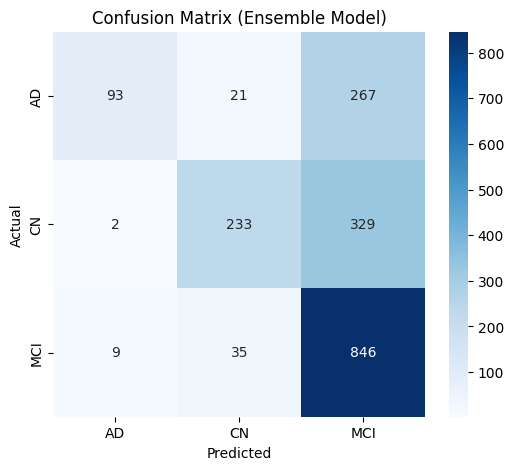

In [3]:
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

from monai.transforms import Compose, LoadImaged, EnsureChannelFirstd, ScaleIntensityd
from monai.data import Dataset, DataLoader

from xgboost import XGBClassifier
from torchvision.models import densenet121
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight

# =========================
# 1. LOAD CSV
# =========================
df = pd.read_csv(r"D:\ADNI_paths_labels.csv")
df = df[['filepath', 'label']].dropna()

le = LabelEncoder()
df['label_id'] = le.fit_transform(df['label'])

data_dicts = [
    {"image": row.filepath, "label": row.label_id}
    for _, row in df.iterrows()
]

train_data, test_data = train_test_split(
    data_dicts,
    test_size=0.2,
    stratify=df['label_id'],
    random_state=42
)

# =========================
# 2. MONAI TRANSFORMS
# =========================
transforms = Compose([
    LoadImaged(keys=["image"]),
    EnsureChannelFirstd(keys=["image"]),
    ScaleIntensityd(keys=["image"])
])

train_ds = Dataset(train_data, transform=transforms)
train_loader = DataLoader(train_ds, batch_size=1, shuffle=False)

# =========================
# 3. DENSENET FEATURE EXTRACTOR
# =========================
model = densenet121(weights="IMAGENET1K_V1")

# Fix input channel
model.features.conv0 = torch.nn.Conv2d(
    1, 64, kernel_size=7, stride=2, padding=3, bias=False
)

feature_extractor = model.features
feature_extractor.add_module("pool", torch.nn.AdaptiveAvgPool2d(1))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

# =========================
# 4. FEATURE EXTRACTION
# =========================
X, y = [], []

with torch.no_grad():
    for batch in train_loader:

        img = torch.as_tensor(batch["image"]).squeeze().cpu().numpy()

        if len(img.shape) != 3:
            continue

        axial = img[:, :, img.shape[2] // 2]
        coronal = img[:, img.shape[1] // 2, :]
        sagittal = img[img.shape[0] // 2, :, :]

        views = [axial, coronal, sagittal]
        feats = []

        for v in views:
            v = torch.tensor(v, dtype=torch.float32)
            v = v.unsqueeze(0).unsqueeze(0)

            v = F.interpolate(
                v,
                size=(224, 224),
                mode="bilinear",
                align_corners=False
            )

            v = v.to(device)

            f = feature_extractor(v)
            f = f.view(f.size(0), -1)

            feats.append(f.cpu().numpy())

        final_feat = np.concatenate(feats, axis=1)

        X.append(final_feat.squeeze())
        y.append(batch["label"].item())

X = np.array(X)
y = np.array(y)

print("Feature shape:", X.shape)
# =========================
# 5. PREPARE DATA
# =========================
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA (VERY IMPORTANT)
pca = PCA(n_components=300)
X_pca = pca.fit_transform(X_scaled)

# =========================
# 6. MODELS
# =========================
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

xgb = XGBClassifier(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=6,
    min_child_weight=3,
    gamma=0.2,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,
    reg_lambda=1.5,
    objective='multi:softprob',
    num_class=len(np.unique(y)),
    tree_method='hist',
    random_state=42
)

rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

# =========================
# 7. CROSS VALIDATION + ENSEMBLE
# =========================
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_true_all = []
y_pred_all = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_pca, y)):
    print(f"\n===== Fold {fold+1} =====")

    X_train, X_val = X_pca[train_idx], X_pca[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # Train models
    xgb.fit(X_train, y_train)
    rf.fit(X_train, y_train)

    # Predict probabilities
    xgb_probs = xgb.predict_proba(X_val)
    rf_probs = rf.predict_proba(X_val)

    # 🔥 ENSEMBLE (Weighted Average)
    final_probs = (0.6 * xgb_probs) + (0.4 * rf_probs)

    y_pred = np.argmax(final_probs, axis=1)

    acc = accuracy_score(y_val, y_pred)
    print(f"Fold Accuracy: {acc:.4f}")

    y_true_all.extend(y_val)
    y_pred_all.extend(y_pred)

# =========================
# 8. FINAL EVALUATION
# =========================
from sklearn.metrics import classification_report, confusion_matrix

print("\n===== FINAL CLASSIFICATION REPORT =====\n")
print(classification_report(
    y_true_all,
    y_pred_all,
    target_names=le.classes_
))

# =========================
# 9. CONFUSION MATRIX
# =========================
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true_all, y_pred_all)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Ensemble Model)")
plt.show()

In [45]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, ScaleIntensityd
)
from monai.data import Dataset, DataLoader

from torchvision.models import densenet121

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report

from xgboost import XGBClassifier

# =========================
# 1. LOAD DATA
# =========================
df = pd.read_csv(r"D:\ADNI_paths_labels.csv")
df = df[['filepath', 'label']].dropna()

le = LabelEncoder()
df['label_id'] = le.fit_transform(df['label'])

data_dicts = [
    {"image": row.filepath, "label": row.label_id}
    for _, row in df.iterrows()
]

train_data, test_data = train_test_split(
    data_dicts,
    test_size=0.2,
    stratify=df['label_id'],
    random_state=42
)

# =========================
# 2. MONAI PIPELINE
# =========================
transforms = Compose([
    LoadImaged(keys=["image"]),
    EnsureChannelFirstd(keys=["image"]),
    ScaleIntensityd(keys=["image"])
])

train_ds = Dataset(train_data, transform=transforms)
train_loader = DataLoader(train_ds, batch_size=1, shuffle=False)

# =========================
# 3. DENSENET (FIXED FOR 1 CHANNEL)
# =========================
model = densenet121(weights="IMAGENET1K_V1")

model.features.conv0 = torch.nn.Conv2d(
    1, 64,
    kernel_size=7,
    stride=2,
    padding=3,
    bias=False
)

feature_extractor = model.features
feature_extractor.add_module("pool", torch.nn.AdaptiveAvgPool2d(1))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

# =========================
# 4. FEATURE EXTRACTION (MULTI-VIEW)
# =========================
X, y = [], []

with torch.no_grad():
    for batch in train_loader:

        img = torch.as_tensor(batch["image"]).squeeze().cpu().numpy()

        if len(img.shape) != 3:
            continue

        # 3 views
        axial = img[:, :, img.shape[2] // 2]
        coronal = img[:, img.shape[1] // 2, :]
        sagittal = img[img.shape[0] // 2, :, :]

        views = [axial, coronal, sagittal]
        feat_list = []

        for v in views:

            v = torch.tensor(v, dtype=torch.float32)
            v = v.unsqueeze(0).unsqueeze(0)

            v = F.interpolate(
                v,
                size=(224, 224),
                mode="bilinear",
                align_corners=False
            )

            f = feature_extractor(v.to(device))
            f = f.view(f.size(0), -1)

            feat_list.append(f.cpu().numpy())

        final_feat = np.concatenate(feat_list, axis=1)

        X.append(final_feat.squeeze())
        y.append(batch["label"].item())

X = np.array(X)
y = np.array(y)

print("Raw feature shape:", X.shape)

# =========================
# 5. SAVE RAW FEATURES (IMPORTANT)
# =========================
save_dir = r"D:\ADNI_features"
os.makedirs(save_dir, exist_ok=True)

np.save(os.path.join(save_dir, "X_raw.npy"), X)
np.save(os.path.join(save_dir, "y.npy"), y)

print("Features saved ✔")

# =========================
# 6. NORMALIZATION
# =========================
scaler = StandardScaler()
X = scaler.fit_transform(X)

# =========================
# 7. PCA (DIMENSION REDUCTION)
# =========================
pca = PCA(n_components=512)
X = pca.fit_transform(X)

print("After PCA shape:", X.shape)

# Save processed features
np.save(os.path.join(save_dir, "X_pca.npy"), X)

# =========================
# 8. TRAIN / TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# =========================
# 9. CLASS WEIGHTS (IMBALANCE FIX)
# =========================
classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

weight_dict = dict(zip(classes, weights))
sample_weights = np.array([weight_dict[i] for i in y_train])

# =========================
# 10. XGBOOST MODEL
# =========================
clf = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    gamma=1,
    reg_lambda=1,
    eval_metric="mlogloss"
)

clf.fit(X_train, y_train, sample_weight=sample_weights)

# =========================
# 11. EVALUATION
# =========================
y_pred = clf.predict(X_test)

print("\nClassification Report:\n")
print(classification_report(
    y_test,
    y_pred,
    target_names=le.classes_
))

Raw feature shape: (1835, 3072)
Features saved ✔
After PCA shape: (1835, 512)

Classification Report:

              precision    recall  f1-score   support

          AD       0.68      0.30      0.42        76
          CN       0.64      0.52      0.58       113
         MCI       0.62      0.84      0.72       178

    accuracy                           0.63       367
   macro avg       0.65      0.56      0.57       367
weighted avg       0.64      0.63      0.61       367



Loaded: (1835, 512) (1835,)

========== FOLD 1 ==========
Train Accuracy: 1.0
Test Accuracy: 0.6376021798365122

Train Confusion Matrix


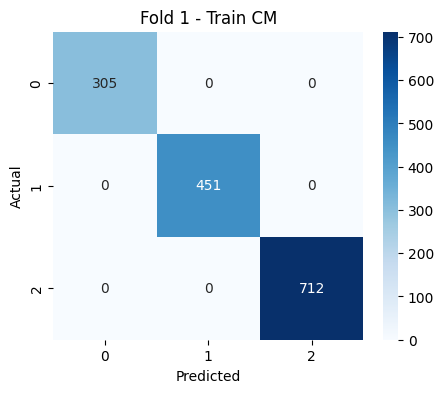


Test Confusion Matrix


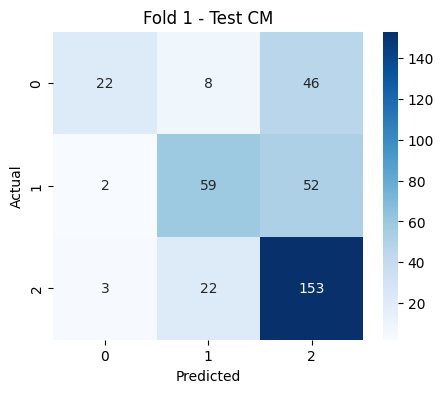


========== FOLD 2 ==========
Train Accuracy: 1.0
Test Accuracy: 0.6267029972752044

Train Confusion Matrix


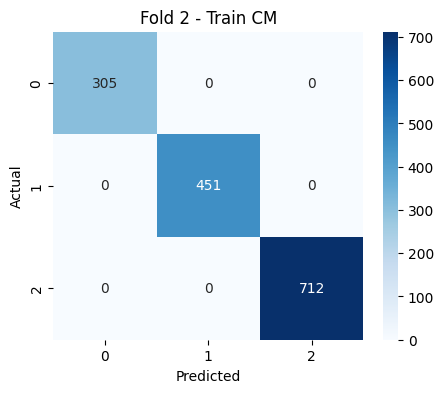


Test Confusion Matrix


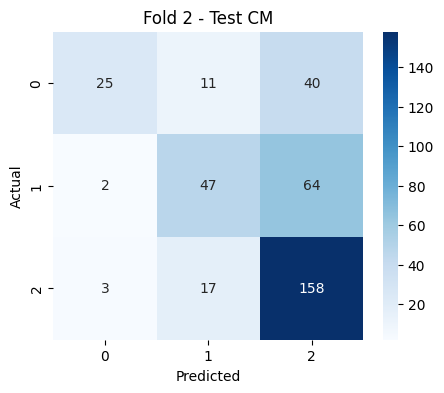


========== FOLD 3 ==========
Train Accuracy: 1.0
Test Accuracy: 0.6348773841961853

Train Confusion Matrix


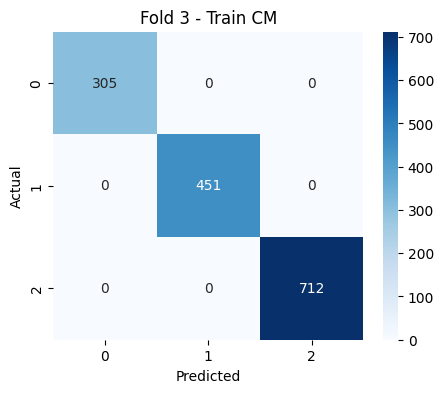


Test Confusion Matrix


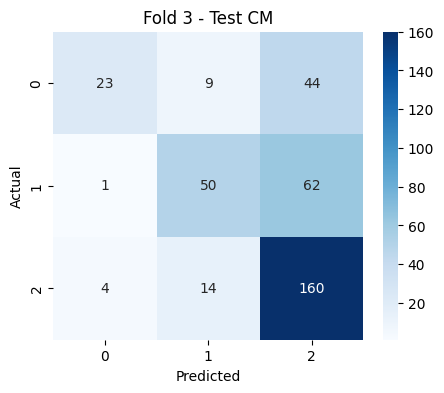


========== FOLD 4 ==========
Train Accuracy: 1.0
Test Accuracy: 0.6076294277929155

Train Confusion Matrix


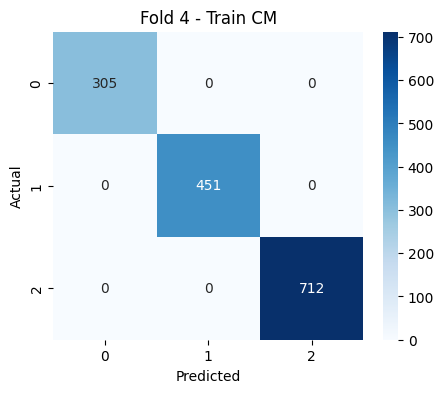


Test Confusion Matrix


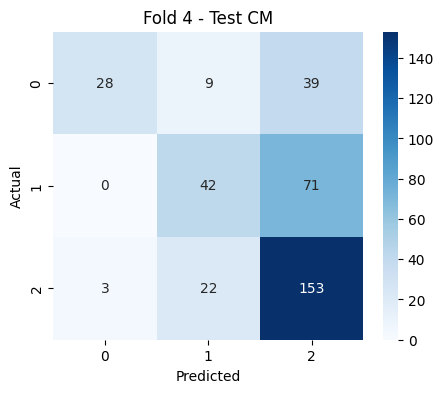


========== FOLD 5 ==========
Train Accuracy: 1.0
Test Accuracy: 0.6212534059945504

Train Confusion Matrix


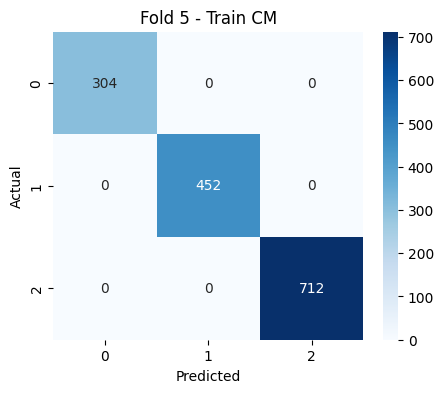


Test Confusion Matrix


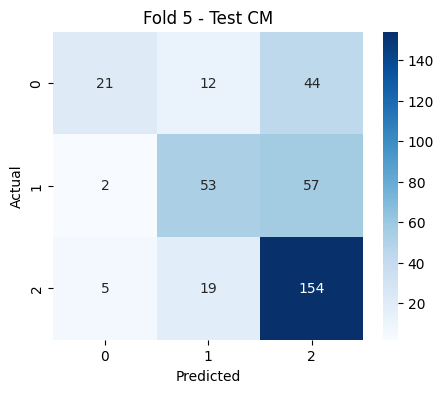


FINAL CROSS VALIDATION RESULT
Mean Train Accuracy: 1.0
Mean Test Accuracy: 0.6256130790190736
Std Test Accuracy: 0.010706748067786664


In [46]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

from xgboost import XGBClassifier
import seaborn as sns


# =========================
# LOAD YOUR SAVED FEATURES
# =========================
X = np.load(r"D:\ADNI_features\X_pca.npy")
y = np.load(r"D:\ADNI_features\y.npy")

print("Loaded:", X.shape, y.shape)


# =========================
# CROSS VALIDATION SETUP
# =========================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold = 1

train_accs = []
test_accs = []


# =========================
# FUNCTION: PLOT CONFUSION MATRIX
# =========================
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


# =========================
# CROSS VALIDATION LOOP
# =========================
for train_idx, test_idx in skf.split(X, y):

    print(f"\n========== FOLD {fold} ==========")

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # =========================
    # CLASS WEIGHTS
    # =========================
    classes = np.unique(y_train)

    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_train
    )

    weight_dict = dict(zip(classes, weights))
    sample_weights = np.array([weight_dict[i] for i in y_train])

    # =========================
    # MODEL
    # =========================
    model = XGBClassifier(
        n_estimators=400,
        max_depth=5,
        learning_rate=0.03,
        subsample=0.9,
        colsample_bytree=0.9,
        gamma=1,
        reg_lambda=1,
        eval_metric="mlogloss"
    )

    model.fit(X_train, y_train, sample_weight=sample_weights)

    # =========================
    # PREDICTIONS
    # =========================
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # =========================
    # ACCURACY
    # =========================
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    train_accs.append(train_acc)
    test_accs.append(test_acc)

    print("Train Accuracy:", train_acc)
    print("Test Accuracy:", test_acc)

    # =========================
    # CONFUSION MATRICES
    # =========================
    print("\nTrain Confusion Matrix")
    plot_cm(y_train, y_train_pred, f"Fold {fold} - Train CM")

    print("\nTest Confusion Matrix")
    plot_cm(y_test, y_test_pred, f"Fold {fold} - Test CM")

    fold += 1


# =========================
# FINAL SUMMARY
# =========================
print("\n=========================")
print("FINAL CROSS VALIDATION RESULT")
print("=========================")

print("Mean Train Accuracy:", np.mean(train_accs))
print("Mean Test Accuracy:", np.mean(test_accs))
print("Std Test Accuracy:", np.std(test_accs))

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

# =========================
# 1. LOAD FEATURES
# =========================
X = np.load(r"D:\ADNI_features\X_pca.npy")
y = np.load(r"D:\ADNI_features\y.npy")

# IMPORTANT: load metadata for subject IDs
df = pd.read_csv(r"D:\ADNI_paths_labels.csv")

# Extract subject ID (first part before "_")
df["subject_id"] = df["filepath"].apply(lambda x: x.split("\\")[-1].split("_")[0])

groups = df["subject_id"].values

print("X:", X.shape, "y:", y.shape, "groups:", len(groups))


# =========================
# 2. CROSS VALIDATION SETUP
# =========================
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

fold = 1
acc_scores = []


# =========================
# 3. CONFUSION MATRIX PLOT
# =========================
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


# =========================
# 4. CROSS VALIDATION LOOP
# =========================
for train_idx, test_idx in cv.split(X, y, groups):

    print(f"\n========== FOLD {fold} ==========")

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # =========================
    # SMOTE ONLY ON TRAIN
    # =========================
    sm = SMOTE(random_state=42)
    X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

    # =========================
    # CLASS WEIGHTS (optional extra stability)
    # =========================
    classes = np.unique(y_train_res)
    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_train_res
    )
    weight_dict = dict(zip(classes, weights))
    sample_weights = np.array([weight_dict[i] for i in y_train_res])

    # =========================
    # MODEL
    # =========================
    model = XGBClassifier(
        n_estimators=500,
        max_depth=5,
        learning_rate=0.03,
        subsample=0.9,
        colsample_bytree=0.9,
        gamma=1,
        reg_lambda=1,
        eval_metric="mlogloss"
    )

    model.fit(X_train_res, y_train_res, sample_weight=sample_weights)

    # =========================
    # PREDICTIONS
    # =========================
    train_pred = model.predict(X_train_res)
    test_pred = model.predict(X_test)

    # =========================
    # ACCURACY
    # =========================
    train_acc = accuracy_score(y_train_res, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    acc_scores.append(test_acc)

    print("Train Accuracy:", train_acc)
    print("Test Accuracy:", test_acc)

    # =========================
    # CONFUSION MATRICES
    # =========================
    plot_cm(y_train_res, train_pred, f"Fold {fold} - TRAIN CM")
    plot_cm(y_test, test_pred, f"Fold {fold} - TEST CM")

    fold += 1


# =========================
# 5. FINAL REPORT
# =========================
print("\n====================")
print("FINAL CV RESULTS")
print("====================")
print("Mean Accuracy:", np.mean(acc_scores))
print("Std Accuracy:", np.std(acc_scores))

X: (1835, 512) y: (1835,) groups: 2294


ValueError: Found input variables with inconsistent numbers of samples: [1835, 1835, 2294]

In [50]:
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

from torchvision.models import densenet121

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.utils.class_weight import compute_class_weight

from xgboost import XGBClassifier
import seaborn as sns
import matplotlib.pyplot as plt


# =========================
# 1. LOAD METADATA
# =========================
df = pd.read_csv(r"D:\ADNI_paths_labels.csv")
df = df[['filepath', 'label']].dropna()

# Extract subject ID
df["subject_id"] = df["filepath"].apply(
    lambda x: x.split("\\")[-1].split("_")[0]
)

le = LabelEncoder()
df["label_id"] = le.fit_transform(df["label"])


# =========================
# 2. GROUP BY SUBJECT (CRITICAL FIX)
# =========================
subject_groups = df.groupby("subject_id")


# =========================
# 3. DENSENET FEATURE EXTRACTOR
# =========================
model = densenet121(weights="IMAGENET1K_V1")

model.features.conv0 = torch.nn.Conv2d(
    1, 64, kernel_size=7, stride=2, padding=3, bias=False
)

feature_extractor = model.features
feature_extractor.add_module("pool", torch.nn.AdaptiveAvgPool2d(1))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()


# =========================
# 4. SUBJECT-LEVEL FEATURE EXTRACTION
# =========================
X_subject = []
y_subject = []
subject_ids = []

with torch.no_grad():

    for subject_id, group in subject_groups:

        feats_per_subject = []

        # all slices for this subject
        for _, row in group.iterrows():

            img_path = row["filepath"]

            try:
                img = np.load(img_path) if img_path.endswith(".npy") else None
            except:
                continue

            if img is None or len(img.shape) != 3:
                continue

            # 3 views
            axial = img[:, :, img.shape[2] // 2]
            coronal = img[:, img.shape[1] // 2, :]
            sagittal = img[img.shape[0] // 2, :, :]

            views = [axial, coronal, sagittal]

            for v in views:

                v = torch.tensor(v, dtype=torch.float32)
                v = v.unsqueeze(0).unsqueeze(0)

                v = F.interpolate(
                    v,
                    size=(224, 224),
                    mode="bilinear",
                    align_corners=False
                )

                f = feature_extractor(v.to(device))
                f = f.view(f.size(0), -1)

                feats_per_subject.append(f.cpu().numpy().squeeze())

        # =========================
        # SUBJECT AGGREGATION (KEY STEP)
        # =========================
        if len(feats_per_subject) == 0:
            continue

        subject_feature = np.mean(feats_per_subject, axis=0)

        X_subject.append(subject_feature)
        y_subject.append(group["label_id"].values[0])
        subject_ids.append(subject_id)


X = np.array(X_subject)
y = np.array(y_subject)
groups = np.array(subject_ids)

print("Subject-level X shape:", X.shape)


# =========================
# 5. NORMALIZATION + PCA
# =========================
scaler = StandardScaler()
X = scaler.fit_transform(X)

pca = PCA(n_components=256)
X = pca.fit_transform(X)

print("After PCA:", X.shape)


# =========================
# 6. CROSS VALIDATION (NO LEAKAGE)
# =========================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold = 1
scores = []


def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Pred")
    plt.ylabel("True")
    plt.show()


for train_idx, test_idx in cv.split(X, y):

    print(f"\n===== FOLD {fold} =====")

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # class weights (NO SMOTE - safer for medical data)
    classes = np.unique(y_train)

    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_train
    )

    weight_dict = dict(zip(classes, weights))
    sample_weights = np.array([weight_dict[i] for i in y_train])

    model = XGBClassifier(
        n_estimators=400,
        max_depth=5,
        learning_rate=0.03,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="mlogloss"
    )

    model.fit(X_train, y_train, sample_weight=sample_weights)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    scores.append(acc)

    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    plot_cm(y_test, y_pred, f"Fold {fold} Confusion Matrix")

    fold += 1


# =========================
# FINAL RESULT
# =========================
print("\nFINAL CV ACCURACY:", np.mean(scores))
print("STD:", np.std(scores))

Subject-level X shape: (0,)


ValueError: Expected 2D array, got 1D array instead:
array=[].
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.

In [51]:
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

from monai.transforms import LoadImage
from torchvision.models import densenet121

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns


# =========================
# 1. LOAD METADATA
# =========================
df = pd.read_csv(r"D:\ADNI1_Complete_1Yr_1.5T_12_20_2024.csv")

df = df[['filepath', 'label']].dropna()

# Subject ID extraction
df["subject_id"] = df["filepath"].apply(
    lambda x: x.split("\\")[-1].split("_")[0]
)

# Encode labels
le = LabelEncoder()
df["label_id"] = le.fit_transform(df["label"])


# =========================
# 2. MONAI LOADER (FIXED)
# =========================
loader = LoadImage(image_only=True)


# =========================
# 3. DENSENET FEATURE EXTRACTOR
# =========================
model = densenet121(weights="IMAGENET1K_V1")

# adapt for grayscale MRI
model.features.conv0 = torch.nn.Conv2d(
    1, 64, kernel_size=7, stride=2, padding=3, bias=False
)

feature_extractor = model.features
feature_extractor.add_module("pool", torch.nn.AdaptiveAvgPool2d(1))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()


# =========================
# 4. SUBJECT-LEVEL FEATURE EXTRACTION
# =========================
subject_groups = df.groupby("subject_id")

X_subject, y_subject, subject_ids = [], [], []

with torch.no_grad():

    for sid, group in subject_groups:

        feats = []

        for _, row in group.iterrows():

            img_path = row["filepath"]

            try:
                img = loader(img_path)   # MONAI SAFE LOAD
            except:
                continue

            if img is None or len(img.shape) != 3:
                continue

            # 3D → 3 views
            axial = img[:, :, img.shape[2] // 2]
            coronal = img[:, img.shape[1] // 2, :]
            sagittal = img[img.shape[0] // 2, :, :]

            for v in [axial, coronal, sagittal]:

                v = torch.tensor(v, dtype=torch.float32)
                v = v.unsqueeze(0).unsqueeze(0)

                v = F.interpolate(
                    v,
                    size=(224, 224),
                    mode="bilinear",
                    align_corners=False
                )

                f = feature_extractor(v.to(device))
                f = f.view(f.size(0), -1)

                feats.append(f.cpu().numpy().squeeze())

        # =========================
        # SAFETY CHECK (CRITICAL)
        # =========================
        if len(feats) == 0:
            print(f"Skipping subject {sid} (no valid slices)")
            continue

        subject_feat = np.mean(feats, axis=0)

        X_subject.append(subject_feat)
        y_subject.append(group["label_id"].values[0])
        subject_ids.append(sid)


X = np.array(X_subject)
y = np.array(y_subject)

print("Final subject-level shape:", X.shape)


# =========================
# 5. SAFE CHECK
# =========================
if len(X) == 0:
    raise ValueError("No features extracted. Check file paths or loading.")


# =========================
# 6. SCALING + PCA
# =========================
scaler = StandardScaler()
X = scaler.fit_transform(X)

pca = PCA(n_components=256)
X = pca.fit_transform(X)

print("After PCA:", X.shape)


# =========================
# 7. CROSS VALIDATION
# =========================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold = 1
scores = []


def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()


for train_idx, test_idx in cv.split(X, y):

    print(f"\n===== FOLD {fold} =====")

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # class weights (NO SMOTE — medical safe)
    classes = np.unique(y_train)

    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_train
    )

    weight_dict = dict(zip(classes, weights))
    sample_weights = np.array([weight_dict[i] for i in y_train])

    model = XGBClassifier(
        n_estimators=400,
        max_depth=5,
        learning_rate=0.03,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="mlogloss"
    )

    model.fit(X_train, y_train, sample_weight=sample_weights)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    scores.append(acc)

    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    plot_cm(y_test, y_pred, f"Fold {fold} Confusion Matrix")

    fold += 1


# =========================
# 8. FINAL RESULTS
# =========================
print("\n======================")
print("FINAL RESULTS")
print("======================")
print("Mean Accuracy:", np.mean(scores))
print("Std Accuracy:", np.std(scores))

KeyError: "None of [Index(['filepath', 'label'], dtype='object')] are in the [columns]"

🔍 Searching files...
✔ Mapped files: 2294


C:\Users\Nimra Nadeem\AppData\Local\Temp\ipykernel_20540\2190281891.py:120: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  v = torch.tensor(v, dtype=torch.float32)


✔ Subject-level shape: (639, 1024)
✔ After PCA: (639, 256)

===== FOLD 1 =====
Accuracy: 0.4453125
              precision    recall  f1-score   support

          AD       0.33      0.07      0.12        27
          CN       0.25      0.10      0.15        39
         MCI       0.48      0.82      0.61        62

    accuracy                           0.45       128
   macro avg       0.35      0.33      0.29       128
weighted avg       0.38      0.45      0.36       128



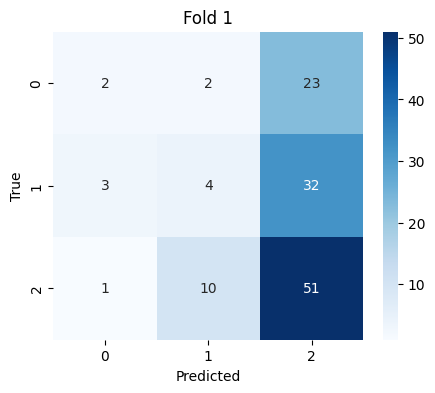


===== FOLD 2 =====
Accuracy: 0.390625
              precision    recall  f1-score   support

          AD       0.00      0.00      0.00        27
          CN       0.22      0.21      0.21        39
         MCI       0.48      0.68      0.56        62

    accuracy                           0.39       128
   macro avg       0.23      0.29      0.26       128
weighted avg       0.30      0.39      0.34       128



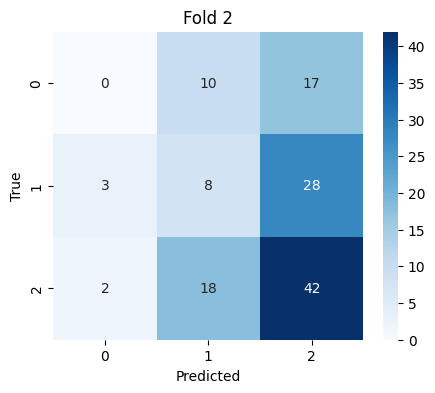


===== FOLD 3 =====
Accuracy: 0.4296875
              precision    recall  f1-score   support

          AD       0.25      0.04      0.06        27
          CN       0.28      0.21      0.24        39
         MCI       0.48      0.74      0.59        62

    accuracy                           0.43       128
   macro avg       0.34      0.33      0.30       128
weighted avg       0.37      0.43      0.37       128



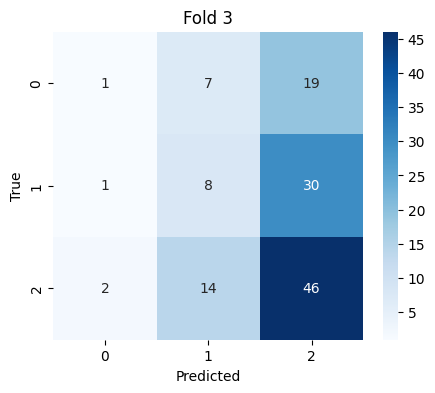


===== FOLD 4 =====
Accuracy: 0.5
              precision    recall  f1-score   support

          AD       0.25      0.04      0.07        26
          CN       0.43      0.33      0.38        39
         MCI       0.53      0.79      0.64        63

    accuracy                           0.50       128
   macro avg       0.41      0.39      0.36       128
weighted avg       0.44      0.50      0.44       128



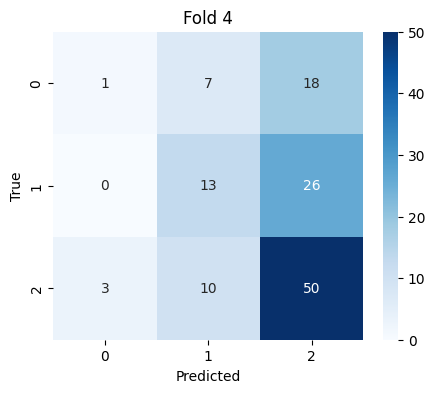


===== FOLD 5 =====
Accuracy: 0.44881889763779526
              precision    recall  f1-score   support

          AD       0.00      0.00      0.00        26
          CN       0.32      0.18      0.23        39
         MCI       0.50      0.81      0.62        62

    accuracy                           0.45       127
   macro avg       0.27      0.33      0.28       127
weighted avg       0.34      0.45      0.37       127



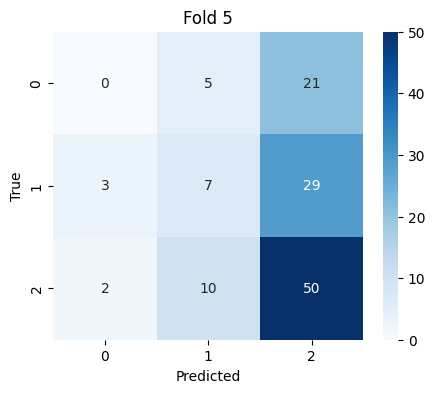


FINAL RESULTS
Mean Accuracy: 0.44288877952755906
Std: 0.03523778840180436


In [53]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

from monai.transforms import LoadImage
from torchvision.models import densenet121

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from xgboost import XGBClassifier


# =========================================================
# 1. LOAD CSV
# =========================================================
csv_path = r"D:\ADNI1_Complete_1Yr_1.5T_12_20_2024.csv"
base_dir = r"D:\ADNI1_Complete 1Yr 1.5T"

df = pd.read_csv(csv_path)

df = df[['Image Data ID', 'Subject', 'Group']].dropna()


# =========================================================
# 2. AUTO FILE PATH MAPPING (NO MANUAL WORK)
# =========================================================
print("🔍 Searching files...")

file_dict = {}

for root, _, files in os.walk(base_dir):
    for f in files:
        if f.endswith((".nii", ".nii.gz")):
            file_dict[f] = os.path.join(root, f)


def find_path(img_id):
    for fname, path in file_dict.items():
        if img_id in fname:
            return path
    return None


df["filepath"] = df["Image Data ID"].apply(find_path)

df = df.dropna(subset=["filepath"])

print("✔ Mapped files:", len(df))


# =========================================================
# 3. LABEL ENCODING
# =========================================================
le = LabelEncoder()
df["label_id"] = le.fit_transform(df["Group"])

df["subject_id"] = df["Subject"]   # CORRECT SUBJECT LEVEL


# =========================================================
# 4. MONAI LOADER
# =========================================================
loader = LoadImage(image_only=True)


# =========================================================
# 5. DENSENET FEATURE EXTRACTOR
# =========================================================
model = densenet121(weights="IMAGENET1K_V1")

model.features.conv0 = torch.nn.Conv2d(
    1, 64, kernel_size=7, stride=2, padding=3, bias=False
)

feature_extractor = model.features
feature_extractor.add_module("pool", torch.nn.AdaptiveAvgPool2d(1))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()


# =========================================================
# 6. SUBJECT-LEVEL FEATURE EXTRACTION
# =========================================================
subject_groups = df.groupby("subject_id")

X, y = [], []

with torch.no_grad():

    for sid, group in subject_groups:

        feats = []

        for _, row in group.iterrows():

            try:
                img = loader(row["filepath"])
            except:
                continue

            if img is None or len(img.shape) != 3:
                continue

            axial = img[:, :, img.shape[2] // 2]
            coronal = img[:, img.shape[1] // 2, :]
            sagittal = img[img.shape[0] // 2, :, :]

            for v in [axial, coronal, sagittal]:

                v = torch.tensor(v, dtype=torch.float32)
                v = v.unsqueeze(0).unsqueeze(0)

                v = F.interpolate(v, size=(224, 224), mode="bilinear", align_corners=False)

                f = feature_extractor(v.to(device))
                f = f.view(f.size(0), -1)

                feats.append(f.cpu().numpy().squeeze())

        if len(feats) == 0:
            continue

        X.append(np.mean(feats, axis=0))
        y.append(group["label_id"].values[0])


X = np.array(X)
y = np.array(y)

print("✔ Subject-level shape:", X.shape)


# =========================================================
# 7. SAFETY CHECK
# =========================================================
if len(X) == 0:
    raise ValueError("No features extracted. Check file structure.")


# =========================================================
# 8. NORMALIZATION + PCA
# =========================================================
scaler = StandardScaler()
X = scaler.fit_transform(X)

pca = PCA(n_components=256)
X = pca.fit_transform(X)

print("✔ After PCA:", X.shape)


# =========================================================
# 9. CROSS VALIDATION
# =========================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold = 1
scores = []


def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()


for train_idx, test_idx in cv.split(X, y):

    print(f"\n===== FOLD {fold} =====")

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    classes = np.unique(y_train)

    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_train
    )

    weight_dict = dict(zip(classes, weights))
    sample_weights = np.array([weight_dict[i] for i in y_train])

    model = XGBClassifier(
        n_estimators=400,
        max_depth=5,
        learning_rate=0.03,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="mlogloss"
    )

    model.fit(X_train, y_train, sample_weight=sample_weights)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    scores.append(acc)

    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    plot_cm(y_test, y_pred, f"Fold {fold}")

    fold += 1


# =========================================================
# 10. FINAL RESULT
# =========================================================
print("\n====================")
print("FINAL RESULTS")
print("====================")
print("Mean Accuracy:", np.mean(scores))
print("Std:", np.std(scores))


========== FOLD 1 ==========
🔵 SVM Accuracy: 0.3515625
              precision    recall  f1-score   support

           0       0.21      0.30      0.25        27
           1       0.35      0.28      0.31        39
           2       0.44      0.42      0.43        62

    accuracy                           0.35       128
   macro avg       0.34      0.33      0.33       128
weighted avg       0.37      0.35      0.36       128



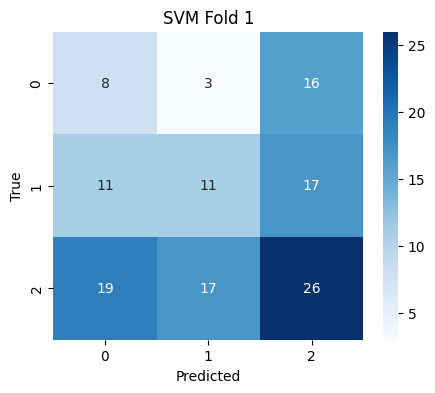

🟢 RF Accuracy: 0.484375
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        27
           1       0.00      0.00      0.00        39
           2       0.48      1.00      0.65        62

    accuracy                           0.48       128
   macro avg       0.16      0.33      0.22       128
weighted avg       0.23      0.48      0.32       128



d:\Anaconda\envs\py310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Anaconda\envs\py310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Anaconda\envs\py310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


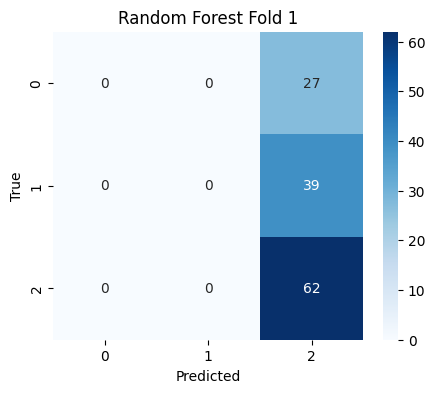


========== FOLD 2 ==========
🔵 SVM Accuracy: 0.3515625
              precision    recall  f1-score   support

           0       0.22      0.33      0.26        27
           1       0.32      0.33      0.33        39
           2       0.50      0.37      0.43        62

    accuracy                           0.35       128
   macro avg       0.35      0.35      0.34       128
weighted avg       0.39      0.35      0.36       128



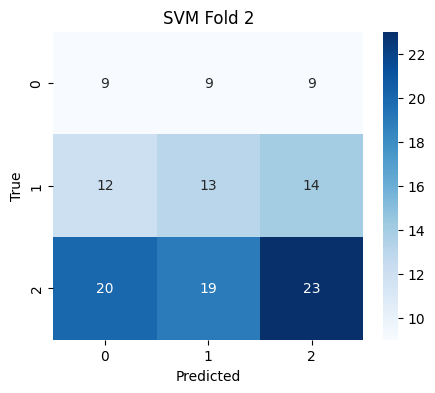

🟢 RF Accuracy: 0.4765625
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        27
           1       0.00      0.00      0.00        39
           2       0.48      0.98      0.65        62

    accuracy                           0.48       128
   macro avg       0.16      0.33      0.22       128
weighted avg       0.23      0.48      0.31       128



d:\Anaconda\envs\py310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Anaconda\envs\py310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Anaconda\envs\py310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


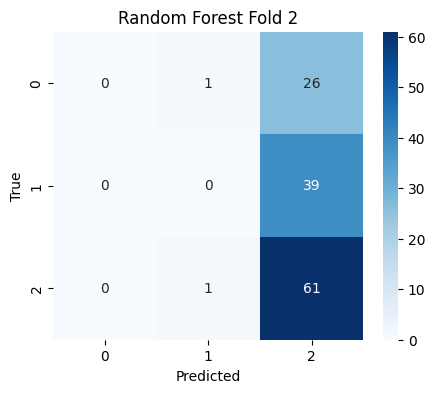


========== FOLD 3 ==========
🔵 SVM Accuracy: 0.359375
              precision    recall  f1-score   support

           0       0.22      0.37      0.27        27
           1       0.37      0.44      0.40        39
           2       0.53      0.31      0.39        62

    accuracy                           0.36       128
   macro avg       0.37      0.37      0.35       128
weighted avg       0.41      0.36      0.37       128



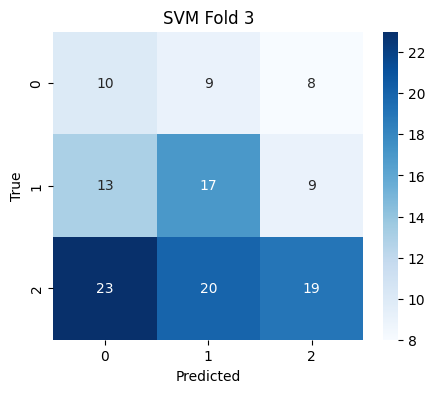

🟢 RF Accuracy: 0.484375
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        27
           1       0.50      0.03      0.05        39
           2       0.48      0.98      0.65        62

    accuracy                           0.48       128
   macro avg       0.33      0.34      0.23       128
weighted avg       0.39      0.48      0.33       128



d:\Anaconda\envs\py310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Anaconda\envs\py310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Anaconda\envs\py310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


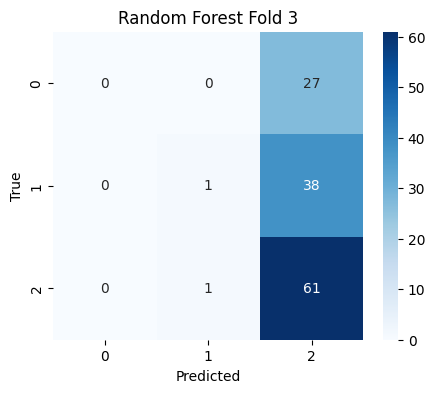


========== FOLD 4 ==========
🔵 SVM Accuracy: 0.3671875
              precision    recall  f1-score   support

           0       0.25      0.35      0.29        26
           1       0.38      0.49      0.43        39
           2       0.45      0.30      0.36        63

    accuracy                           0.37       128
   macro avg       0.36      0.38      0.36       128
weighted avg       0.39      0.37      0.37       128



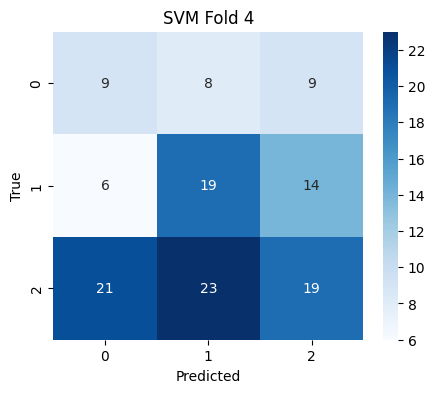

🟢 RF Accuracy: 0.5
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        26
           1       0.67      0.05      0.10        39
           2       0.50      0.98      0.66        63

    accuracy                           0.50       128
   macro avg       0.39      0.35      0.25       128
weighted avg       0.45      0.50      0.35       128



d:\Anaconda\envs\py310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Anaconda\envs\py310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Anaconda\envs\py310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


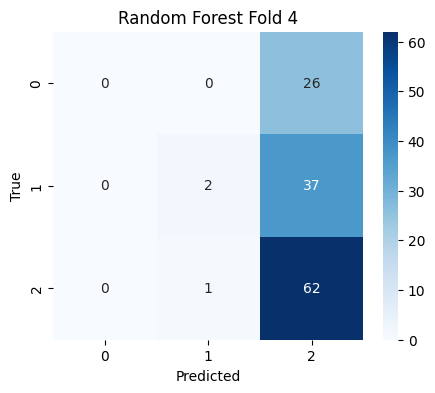


========== FOLD 5 ==========
🔵 SVM Accuracy: 0.41732283464566927
              precision    recall  f1-score   support

           0       0.28      0.46      0.35        26
           1       0.41      0.33      0.37        39
           2       0.54      0.45      0.49        62

    accuracy                           0.42       127
   macro avg       0.41      0.42      0.40       127
weighted avg       0.44      0.42      0.42       127



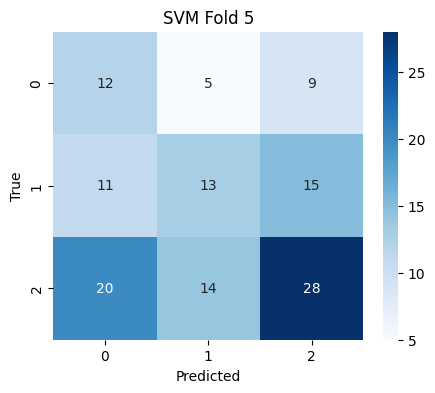

🟢 RF Accuracy: 0.4881889763779528
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        26
           1       0.00      0.00      0.00        39
           2       0.49      1.00      0.66        62

    accuracy                           0.49       127
   macro avg       0.16      0.33      0.22       127
weighted avg       0.24      0.49      0.32       127



d:\Anaconda\envs\py310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Anaconda\envs\py310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Anaconda\envs\py310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


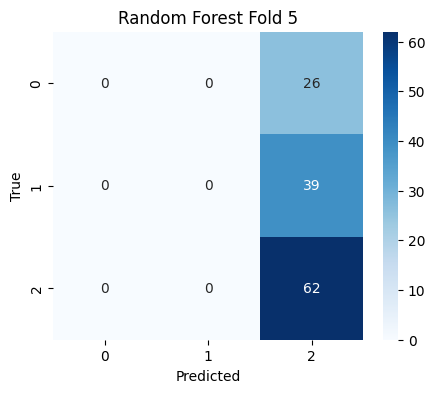


FINAL MODEL COMPARISON
SVM Mean Accuracy: 0.36940206692913385
RF Mean Accuracy: 0.48670029527559056
SVM Std: 0.02465094989190144
RF Std: 0.007650976492816626


In [54]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight


# =========================
# CROSS VALIDATION SETUP
# =========================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


# =========================
# PLOT FUNCTION
# =========================
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()


# =========================
# STORAGE
# =========================
svm_scores = []
rf_scores = []


# =========================
# CROSS VALIDATION LOOP
# =========================
fold = 1

for train_idx, test_idx in cv.split(X, y):

    print(f"\n========== FOLD {fold} ==========")

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # =========================
    # CLASS WEIGHTS
    # =========================
    classes = np.unique(y_train)
    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_train
    )
    weight_dict = dict(zip(classes, weights))
    sample_weights = np.array([weight_dict[i] for i in y_train])


    # =========================================================
    # 1. SVM MODEL
    # =========================================================
    svm = SVC(
        kernel="rbf",
        C=10,
        gamma="scale",
        class_weight="balanced"
    )

    svm.fit(X_train, y_train)

    svm_pred = svm.predict(X_test)

    svm_acc = accuracy_score(y_test, svm_pred)
    svm_scores.append(svm_acc)

    print("🔵 SVM Accuracy:", svm_acc)
    print(classification_report(y_test, svm_pred))

    plot_cm(y_test, svm_pred, f"SVM Fold {fold}")


    # =========================================================
    # 2. RANDOM FOREST MODEL
    # =========================================================
    rf = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        class_weight="balanced",
        random_state=42
    )

    rf.fit(X_train, y_train)

    rf_pred = rf.predict(X_test)

    rf_acc = accuracy_score(y_test, rf_pred)
    rf_scores.append(rf_acc)

    print("🟢 RF Accuracy:", rf_acc)
    print(classification_report(y_test, rf_pred))

    plot_cm(y_test, rf_pred, f"Random Forest Fold {fold}")


    fold += 1


# =========================
# FINAL COMPARISON
# =========================
print("\n========================")
print("FINAL MODEL COMPARISON")
print("========================")

print("SVM Mean Accuracy:", np.mean(svm_scores))
print("RF Mean Accuracy:", np.mean(rf_scores))

print("SVM Std:", np.std(svm_scores))
print("RF Std:", np.std(rf_scores))

🔍 Mapping files...
✔ Files mapped: 2294
🧠 Extracting features...


C:\Users\Nimra Nadeem\AppData\Local\Temp\ipykernel_20540\323422913.py:114: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  v = torch.tensor(v, dtype=torch.float32)


✔ Feature shape: (639, 2048)

===== FOLD 1 =====
Accuracy: 0.3828125
              precision    recall  f1-score   support

          AD       0.34      0.52      0.41        27
          CN       0.20      0.15      0.17        39
         MCI       0.51      0.47      0.49        62

    accuracy                           0.38       128
   macro avg       0.35      0.38      0.36       128
weighted avg       0.38      0.38      0.38       128



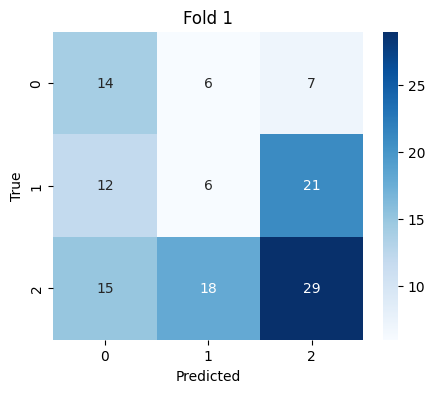


===== FOLD 2 =====
Accuracy: 0.3984375
              precision    recall  f1-score   support

          AD       0.27      0.44      0.33        27
          CN       0.38      0.38      0.38        39
         MCI       0.56      0.39      0.46        62

    accuracy                           0.40       128
   macro avg       0.40      0.41      0.39       128
weighted avg       0.44      0.40      0.41       128



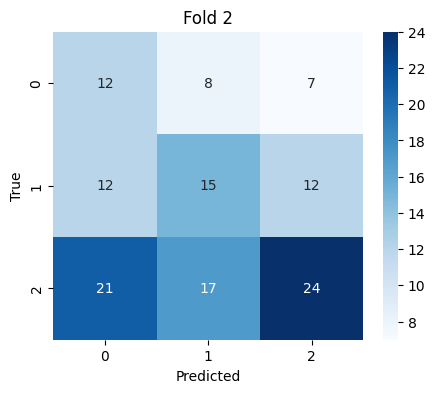


===== FOLD 3 =====
Accuracy: 0.359375
              precision    recall  f1-score   support

          AD       0.16      0.26      0.20        27
          CN       0.32      0.26      0.29        39
         MCI       0.55      0.47      0.50        62

    accuracy                           0.36       128
   macro avg       0.34      0.33      0.33       128
weighted avg       0.40      0.36      0.37       128



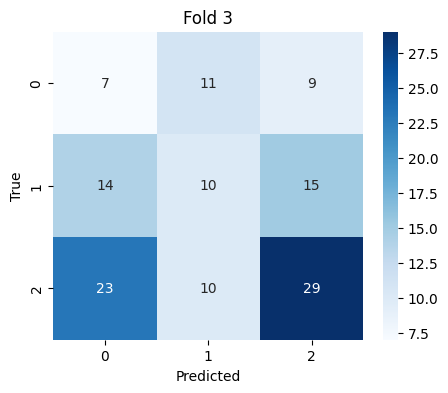


===== FOLD 4 =====
Accuracy: 0.4140625
              precision    recall  f1-score   support

          AD       0.27      0.42      0.33        26
          CN       0.42      0.54      0.47        39
         MCI       0.57      0.33      0.42        63

    accuracy                           0.41       128
   macro avg       0.42      0.43      0.41       128
weighted avg       0.46      0.41      0.42       128



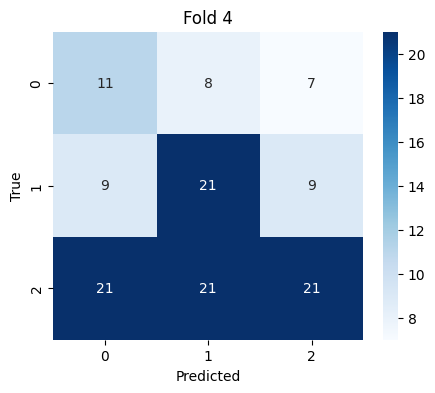


===== FOLD 5 =====
Accuracy: 0.4094488188976378
              precision    recall  f1-score   support

          AD       0.28      0.42      0.34        26
          CN       0.36      0.38      0.37        39
         MCI       0.57      0.42      0.48        62

    accuracy                           0.41       127
   macro avg       0.40      0.41      0.40       127
weighted avg       0.44      0.41      0.42       127



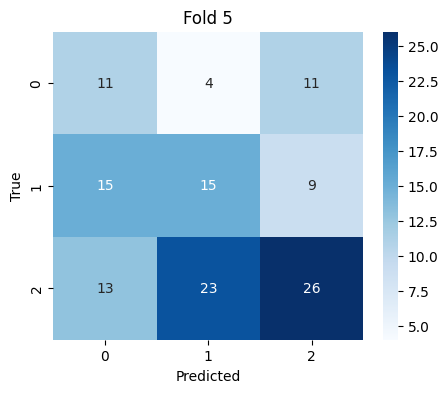


FINAL RESULTS
Mean Accuracy: 0.39282726377952754
Std: 0.019889874548965715


In [55]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

from monai.transforms import LoadImage
from torchvision.models import densenet121

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils import resample

from sklearn.svm import SVC


# =========================================================
# 1. LOAD CSV
# =========================================================
csv_path = r"D:\ADNI1_Complete_1Yr_1.5T_12_20_2024.csv"
base_dir = r"D:\ADNI1_Complete 1Yr 1.5T"

df = pd.read_csv(csv_path)
df = df[['Image Data ID', 'Subject', 'Group']].dropna()


# =========================================================
# 2. AUTO FILE MAPPING
# =========================================================
print("🔍 Mapping files...")

file_dict = {}
for root, _, files in os.walk(base_dir):
    for f in files:
        if f.endswith((".nii", ".nii.gz")):
            file_dict[f] = os.path.join(root, f)

def find_path(img_id):
    for fname, path in file_dict.items():
        if img_id in fname:
            return path
    return None

df["filepath"] = df["Image Data ID"].apply(find_path)
df = df.dropna(subset=["filepath"])

print("✔ Files mapped:", len(df))


# =========================================================
# 3. LABELS
# =========================================================
le = LabelEncoder()
df["label_id"] = le.fit_transform(df["Group"])
df["subject_id"] = df["Subject"]


# =========================================================
# 4. MONAI LOADER
# =========================================================
loader = LoadImage(image_only=True)


# =========================================================
# 5. DENSENET FEATURE EXTRACTOR
# =========================================================
model = densenet121(weights="IMAGENET1K_V1")

model.features.conv0 = torch.nn.Conv2d(
    1, 64, kernel_size=7, stride=2, padding=3, bias=False
)

feature_extractor = model.features
feature_extractor.add_module("pool", torch.nn.AdaptiveAvgPool2d(1))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()


# =========================================================
# 6. SUBJECT-LEVEL FEATURE EXTRACTION (IMPROVED)
# =========================================================
print("🧠 Extracting features...")

subject_groups = df.groupby("subject_id")

X, y = [], []

with torch.no_grad():
    for sid, group in subject_groups:

        feats = []

        for _, row in group.iterrows():
            try:
                img = loader(row["filepath"])
            except:
                continue

            if img is None or len(img.shape) != 3:
                continue

            axial = img[:, :, img.shape[2] // 2]
            coronal = img[:, img.shape[1] // 2, :]
            sagittal = img[img.shape[0] // 2, :, :]

            for v in [axial, coronal, sagittal]:

                v = torch.tensor(v, dtype=torch.float32)
                v = v.unsqueeze(0).unsqueeze(0)

                v = F.interpolate(v, size=(224, 224), mode="bilinear", align_corners=False)

                f = feature_extractor(v.to(device))
                f = f.view(f.size(0), -1)

                feats.append(f.cpu().numpy().squeeze())

        if len(feats) == 0:
            continue

        # 🔥 IMPROVED REPRESENTATION
        mean_feat = np.mean(feats, axis=0)
        max_feat  = np.max(feats, axis=0)

        subject_feat = np.concatenate([mean_feat, max_feat])

        X.append(subject_feat)
        y.append(group["label_id"].values[0])


X = np.array(X)
y = np.array(y)

print("✔ Feature shape:", X.shape)


# =========================================================
# 7. CROSS VALIDATION
# =========================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = []
fold = 1


def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()


for train_idx, test_idx in cv.split(X, y):

    print(f"\n===== FOLD {fold} =====")

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # =========================================================
    # 🔥 CLASS BALANCING (CRITICAL)
    # =========================================================
    train_df = pd.DataFrame(X_train)
    train_df["label"] = y_train

    max_size = train_df["label"].value_counts().max()

    balanced = []
    for label in train_df["label"].unique():
        subset = train_df[train_df["label"] == label]
        balanced.append(resample(subset, replace=True, n_samples=max_size, random_state=42))

    train_bal = pd.concat(balanced)

    X_train = train_bal.drop("label", axis=1).values
    y_train = train_bal["label"].values

    # =========================================================
    # SCALING + PCA
    # =========================================================
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    pca = PCA(n_components=0.95)
    X_train = pca.fit_transform(X_train)
    X_test  = pca.transform(X_test)

    # =========================================================
    # SVM MODEL (BEST FOR THIS SETUP)
    # =========================================================
    model = SVC(kernel="rbf", C=10, gamma="scale", class_weight="balanced")

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    scores.append(acc)

    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    plot_cm(y_test, y_pred, f"Fold {fold}")

    fold += 1


# =========================================================
# FINAL RESULT
# =========================================================
print("\n======================")
print("FINAL RESULTS")
print("======================")
print("Mean Accuracy:", np.mean(scores))
print("Std:", np.std(scores))

In [5]:
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

from monai.transforms import Compose, LoadImaged, EnsureChannelFirstd, ScaleIntensityd
from monai.data import Dataset, DataLoader
from torchvision.models import densenet121

# =========================
# LOAD CSV
# =========================
df = pd.read_csv(r"D:\ADNI_paths_labels.csv")
df = df[['filepath', 'label']].dropna()

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['label_id'] = le.fit_transform(df['label'])

data_dicts = [{"image": row.filepath, "label": row.label_id} for _, row in df.iterrows()]

# =========================
# TRANSFORMS
# =========================
transforms = Compose([
    LoadImaged(keys=["image"]),
    EnsureChannelFirstd(keys=["image"]),
    ScaleIntensityd(keys=["image"])
])

dataset = Dataset(data_dicts, transform=transforms)
loader = DataLoader(dataset, batch_size=1, shuffle=False)

# =========================
# MODEL
# =========================
model = densenet121(weights="IMAGENET1K_V1")
model.features.conv0 = torch.nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

feature_extractor = model.features
feature_extractor.add_module("pool", torch.nn.AdaptiveAvgPool2d(1))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

# =========================
# EXTRACT FEATURES
# =========================
X_img, y, ids = [], [], []

with torch.no_grad():
    for batch in loader:

        path = batch["image_meta_dict"]["filename_or_obj"][0]
        img_id = path.split("\\")[-1].split("_")[0]

        img = torch.as_tensor(batch["image"]).squeeze().cpu().numpy()
        if len(img.shape) != 3:
            continue

        # multi-view
        axial = img[:, :, img.shape[2] // 2]
        coronal = img[:, img.shape[1] // 2, :]
        sagittal = img[img.shape[0] // 2, :, :]

        views = [axial, coronal, sagittal]
        feats = []

        for v in views:
            v = torch.tensor(v, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
            v = F.interpolate(v, size=(224,224), mode="bilinear", align_corners=False)
            v = v.to(device)

            f = feature_extractor(v)
            f = f.view(f.size(0), -1)

            feats.append(f.cpu().numpy())

        final_feat = np.concatenate(feats, axis=1)

        X_img.append(final_feat.squeeze())
        y.append(batch["label"].item())
        ids.append(img_id)

# SAVE
np.save("image_embeddings.npy", np.array(X_img))
np.save("labels.npy", np.array(y))
np.save("image_ids.npy", np.array(ids))

print("✅ MRI embeddings saved")

KeyError: 'image_meta_dict'

In [6]:
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

from monai.transforms import Compose, LoadImaged, EnsureChannelFirstd, ScaleIntensityd
from monai.data import Dataset, DataLoader
from torchvision.models import densenet121
from sklearn.preprocessing import LabelEncoder

# =========================
# 1. LOAD CSV
# =========================
df = pd.read_csv(r"D:\ADNI_paths_labels.csv")
df = df[['filepath', 'label']].dropna()

le = LabelEncoder()
df['label_id'] = le.fit_transform(df['label'])

# 🔥 IMPORTANT FIX: store filepath explicitly``
data_dicts = [
    {
        "image": row.filepath,
        "label": row.label_id,
        "img_path": row.filepath   # ✅ FIX
    }
    for _, row in df.iterrows()
]

# =========================
# 2. TRANSFORMS
# =========================
transforms = Compose([
    LoadImaged(keys=["image"]),
    EnsureChannelFirstd(keys=["image"]),
    ScaleIntensityd(keys=["image"])
])

dataset = Dataset(data_dicts, transform=transforms)
loader = DataLoader(dataset, batch_size=1, shuffle=False)

# =========================
# 3. MODEL (DENSENET)
# =========================
model = densenet121(weights="IMAGENET1K_V1")

# Fix for grayscale MRI
model.features.conv0 = torch.nn.Conv2d(
    1, 64, kernel_size=7, stride=2, padding=3, bias=False
)

feature_extractor = model.features
feature_extractor.add_module("pool", torch.nn.AdaptiveAvgPool2d(1))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

# =========================
# 4. FEATURE EXTRACTION
# =========================
X_img, y, ids = [], [], []

with torch.no_grad():
    for batch in loader:

        # ✅ FIXED: use img_path instead of MONAI metadata
        path = batch["img_path"][0]
        img_id = path.split("\\")[-1].split("_")[0]

        img = torch.as_tensor(batch["image"]).squeeze().cpu().numpy()

        # Skip bad samples
        if len(img.shape) != 3:
            continue

        # Multi-view slices
        axial = img[:, :, img.shape[2] // 2]
        coronal = img[:, img.shape[1] // 2, :]
        sagittal = img[img.shape[0] // 2, :, :]

        views = [axial, coronal, sagittal]
        feats = []

        for v in views:
            v = torch.tensor(v, dtype=torch.float32).unsqueeze(0).unsqueeze(0)

            v = F.interpolate(
                v,
                size=(224, 224),
                mode="bilinear",
                align_corners=False
            )

            v = v.to(device)

            f = feature_extractor(v)
            f = f.view(f.size(0), -1)

            feats.append(f.cpu().numpy())

        final_feat = np.concatenate(feats, axis=1)

        X_img.append(final_feat.squeeze())
        y.append(batch["label"].item())
        ids.append(img_id)

# =========================
# 5. SAVE EMBEDDINGS
# =========================
X_img = np.array(X_img)
y = np.array(y)
ids = np.array(ids)

np.save("image_embeddings.npy", X_img)
np.save("labels.npy", y)
np.save("image_ids.npy", ids)

print("✅ MRI embeddings saved successfully")
print("Shape:", X_img.shape)

✅ MRI embeddings saved successfully
Shape: (2294, 3072)


In [7]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler

meta_df = pd.read_csv(r"D:\ADNI1_Merged_MRI_Metadata.csv")

# Drop unnecessary columns
drop_cols = [
    "Downloaded", "Modality", "Type", "Format",
    "Visit", "VISCODE", "VISCODE2",
    "USERDATE", "USERDATE2", "update_stamp",
    "Acq Date", "PTID", "RID", "ID", "SITEID"
]

meta_df = meta_df.drop(columns=[col for col in drop_cols if col in meta_df.columns])

# Remove label to avoid leakage
if 'Group' in meta_df.columns:
    meta_df = meta_df.drop(columns=['Group'])

# =========================
# HANDLE MISSING VALUES
# =========================
meta_df = meta_df.fillna(meta_df.median(numeric_only=True))

# =========================
# ENCODE CATEGORICAL
# =========================
for col in meta_df.select_dtypes(include='object').columns:
    if col != "Image Data ID":
        meta_df[col] = LabelEncoder().fit_transform(meta_df[col].astype(str))

# =========================
# SEPARATE IDS + FEATURES
# =========================
ids = meta_df["Image Data ID"].values
X_tab = meta_df.drop(columns=["Image Data ID"]).values

# =========================
# SCALE
# =========================
scaler = StandardScaler()
X_tab = scaler.fit_transform(X_tab)

print("Tabular shape:", X_tab.shape)

Tabular shape: (1464, 34)


In [9]:
from xgboost import XGBClassifier

# Load labels from MRI stage
y = np.load("labels.npy")

# Train temporary model
xgb_fs = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    random_state=42
)

xgb_fs.fit(X_tab, y)

# Get feature importance
importances = xgb_fs.feature_importances_

# Select top-k features
k = 20   # 🔥 tune this (15–30 works best)
top_idx = np.argsort(importances)[::-1][:k]

X_tab_selected = X_tab[:, top_idx]

print("Selected tabular shape:", X_tab_selected.shape)

XGBoostError: [19:21:17] C:\Users\task_177465309458303\croot\xgboost-split_1774653200626\work\src\data\data.cc:522: Check failed: p_info->Size() % n_samples == 0 (830 vs. 0) : Invalid size for `label`:(2294,1). n_samples:1464

In [10]:
import numpy as np
import pandas as pd

# MRI
X_img = np.load("image_embeddings.npy")
y = np.load("labels.npy")
img_ids = np.load("image_ids.npy")

# Metadata
meta_df = pd.read_csv(r"D:\ADNI1_Merged_MRI_Metadata.csv")

In [11]:
drop_cols = [
    "Downloaded", "Modality", "Type", "Format",
    "Visit", "VISCODE", "VISCODE2",
    "USERDATE", "USERDATE2", "update_stamp",
    "Acq Date", "PTID", "RID", "ID", "SITEID"
]

meta_df = meta_df.drop(columns=[col for col in drop_cols if col in meta_df.columns])

if 'Group' in meta_df.columns:
    meta_df = meta_df.drop(columns=['Group'])

meta_df = meta_df.fillna(meta_df.median(numeric_only=True))

from sklearn.preprocessing import LabelEncoder, StandardScaler

for col in meta_df.select_dtypes(include='object').columns:
    if col != "Image Data ID":
        meta_df[col] = LabelEncoder().fit_transform(meta_df[col].astype(str))

In [12]:
meta_ids = meta_df["Image Data ID"].values

# Find common IDs
common_ids = list(set(img_ids).intersection(set(meta_ids)))

print("Common samples:", len(common_ids))

Common samples: 0


In [13]:
print("Sample img_ids:", img_ids[:10])
print("Sample meta_ids:", meta_df["Image Data ID"].head(10).tolist())

Sample img_ids: ['ADNI' 'ADNI' 'ADNI' 'ADNI' 'ADNI' 'ADNI' 'ADNI' 'ADNI' 'ADNI' 'ADNI']
Sample meta_ids: ['I112538', 'I97341', 'I75150', 'I105437', 'I108336', 'I79115', 'I103731', 'I75141', 'I105837', 'I106222']


In [14]:
import os

filename = os.path.basename(path)   # safer than split("\\")
img_id = filename.split("_")[0]

In [15]:
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import os

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from xgboost import XGBClassifier

from monai.transforms import Compose, LoadImaged, EnsureChannelFirstd, ScaleIntensityd
from monai.data import Dataset, DataLoader

from torchvision.models import densenet121

In [16]:
df = pd.read_csv(r"D:\ADNI_paths_labels.csv")
df = df[['filepath', 'label']].dropna()

le = LabelEncoder()
df['label_id'] = le.fit_transform(df['label'])

data_dicts = [
    {
        "image": row.filepath,
        "label": row.label_id,
        "img_path": row.filepath
    }
    for _, row in df.iterrows()
]

In [17]:
transforms = Compose([
    LoadImaged(keys=["image"]),
    EnsureChannelFirstd(keys=["image"]),
    ScaleIntensityd(keys=["image"])
])

dataset = Dataset(data_dicts, transform=transforms)
loader = DataLoader(dataset, batch_size=1, shuffle=False)

In [18]:
model = densenet121(weights="IMAGENET1K_V1")

model.features.conv0 = torch.nn.Conv2d(
    1, 64, kernel_size=7, stride=2, padding=3, bias=False
)

feature_extractor = model.features
feature_extractor.add_module("pool", torch.nn.AdaptiveAvgPool2d(1))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

Sequential(
  (conv0): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu0): ReLU(inplace=True)
  (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (denseblock1): _DenseBlock(
    (denselayer1): _DenseLayer(
      (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu1): ReLU(inplace=True)
      (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu2): ReLU(inplace=True)
      (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    )
    (denselayer2): _DenseLayer(
      (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu1): ReLU(inplace=True)
      (conv1): Conv2d(96, 128, ke

In [19]:
X_img, y, img_ids = [], [], []

with torch.no_grad():
    for batch in loader:

        # ✅ FIXED: correct filename extraction
        path = batch["img_path"][0]
        filename = os.path.basename(path)
        img_id = filename.split("_")[0]

        img = torch.as_tensor(batch["image"]).squeeze().cpu().numpy()

        if len(img.shape) != 3:
            continue

        axial = img[:, :, img.shape[2] // 2]
        coronal = img[:, img.shape[1] // 2, :]
        sagittal = img[img.shape[0] // 2, :, :]

        views = [axial, coronal, sagittal]
        feats = []

        for v in views:
            v = torch.tensor(v, dtype=torch.float32).unsqueeze(0).unsqueeze(0)

            v = F.interpolate(v, size=(224,224), mode="bilinear", align_corners=False)
            v = v.to(device)

            f = feature_extractor(v)
            f = f.view(f.size(0), -1)

            feats.append(f.cpu().numpy())

        final_feat = np.concatenate(feats, axis=1)

        X_img.append(final_feat.squeeze())
        y.append(batch["label"].item())
        img_ids.append(img_id)

X_img = np.array(X_img)
y = np.array(y)
img_ids = np.array(img_ids)

print("MRI embeddings:", X_img.shape)

MRI embeddings: (2294, 3072)


In [30]:
meta_df = pd.read_csv(r"D:\ADNI1_Merged_MRI_Metadata.csv")

drop_cols = [
    "Downloaded","Modality","Type","Format",
    "Visit","VISCODE","VISCODE2",
    "USERDATE","USERDATE2","update_stamp",
    "Acq Date","PTID","RID","ID","SITEID"
]

meta_df = meta_df.drop(columns=[c for c in drop_cols if c in meta_df.columns])

if "Group" in meta_df.columns:
    meta_df = meta_df.drop(columns=["Group"])

meta_df = meta_df.fillna(meta_df.median(numeric_only=True))

for col in meta_df.select_dtypes(include='object').columns:
    if col != "Image Data ID":
        meta_df[col] = LabelEncoder().fit_transform(meta_df[col].astype(str))

meta_df["Image Data ID"] = meta_df["Image Data ID"].astype(str).str.strip()

In [31]:
meta_ids = meta_df["Image Data ID"].values.astype(str)

img_ids = np.array([str(x).strip() for x in img_ids])

common_ids = set(img_ids).intersection(set(meta_ids))

print("Common samples:", len(common_ids))

Common samples: 1464


In [22]:
print(df['filepath'].head(10).values)

['D:\\ADNI1_Complete 1Yr 1.5T\\ADNI\\002_S_0295\\MPR__GradWarp__B1_Correction__N3__Scaled\\2006-04-18_08_20_30.0\\I45108\\ADNI_002_S_0295_MR_MPR__GradWarp__B1_Correction__N3__Scaled_Br_20070319113623975_S13408_I45108.nii'
 'D:\\ADNI1_Complete 1Yr 1.5T\\ADNI\\002_S_0295\\MPR__GradWarp__B1_Correction__N3__Scaled\\2006-11-02_08_16_44.0\\I40966\\ADNI_002_S_0295_MR_MPR__GradWarp__B1_Correction__N3__Scaled_Br_20070219173850420_S21856_I40966.nii'
 'D:\\ADNI1_Complete 1Yr 1.5T\\ADNI\\002_S_0295\\MPR__GradWarp__B1_Correction__N3__Scaled\\2007-05-25_07_12_36.0\\I64025\\ADNI_002_S_0295_MR_MPR__GradWarp__B1_Correction__N3__Scaled_Br_20070802163833409_S32678_I64025.nii'
 'D:\\ADNI1_Complete 1Yr 1.5T\\ADNI\\002_S_0295\\MPR__GradWarp__B1_Correction__N3__Scaled_2\\2006-04-18_08_20_30.0\\I118671\\ADNI_002_S_0295_MR_MPR__GradWarp__B1_Correction__N3__Scaled_2_Br_20081001114556321_S13408_I118671.nii'
 'D:\\ADNI1_Complete 1Yr 1.5T\\ADNI\\002_S_0295\\MPR__GradWarp__B1_Correction__N3__Scaled_2\\2006-11-02_08

In [23]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from xgboost import XGBClassifier

from monai.transforms import Compose, LoadImaged, EnsureChannelFirstd, ScaleIntensityd
from monai.data import Dataset, DataLoader

from torchvision.models import densenet121

In [24]:
df = pd.read_csv(r"D:\ADNI_paths_labels.csv")
df = df[['filepath', 'label']].dropna()

le = LabelEncoder()
df['label_id'] = le.fit_transform(df['label'])

In [25]:
def extract_img_id(path):
    filename = os.path.basename(path)
    filename = filename.replace(".nii", "").replace(".gz", "")
    return filename.split("_")[-1]   # ✔ correct Ixxxxx ID

df["img_id"] = df["filepath"].apply(extract_img_id)

In [26]:
data_dicts = [
    {
        "image": row.filepath,
        "label": row.label_id,
        "img_id": row.img_id
    }
    for _, row in df.iterrows()
]

transforms = Compose([
    LoadImaged(keys=["image"]),
    EnsureChannelFirstd(keys=["image"]),
    ScaleIntensityd(keys=["image"])
])

dataset = Dataset(data_dicts, transform=transforms)
loader = DataLoader(dataset, batch_size=1, shuffle=False)

In [27]:
model = densenet121(weights="IMAGENET1K_V1")

model.features.conv0 = torch.nn.Conv2d(
    1, 64, kernel_size=7, stride=2, padding=3, bias=False
)

feature_extractor = model.features
feature_extractor.add_module("pool", torch.nn.AdaptiveAvgPool2d(1))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

Sequential(
  (conv0): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu0): ReLU(inplace=True)
  (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (denseblock1): _DenseBlock(
    (denselayer1): _DenseLayer(
      (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu1): ReLU(inplace=True)
      (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu2): ReLU(inplace=True)
      (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    )
    (denselayer2): _DenseLayer(
      (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu1): ReLU(inplace=True)
      (conv1): Conv2d(96, 128, ke

In [28]:
X_img, y, img_ids = [], [], []

with torch.no_grad():
    for batch in loader:

        path = batch["image_meta_dict"]["filename_or_obj"][0] if "image_meta_dict" in batch else batch["image"].meta["filename_or_obj"][0]

        img_id = os.path.basename(path).replace(".nii", "").split("_")[-1]

        img = torch.as_tensor(batch["image"]).squeeze().cpu().numpy()

        if len(img.shape) != 3:
            continue

        axial = img[:, :, img.shape[2] // 2]
        coronal = img[:, img.shape[1] // 2, :]
        sagittal = img[img.shape[0] // 2, :, :]

        views = [axial, coronal, sagittal]
        feats = []

        for v in views:
            v = torch.tensor(v, dtype=torch.float32).unsqueeze(0).unsqueeze(0)

            v = F.interpolate(v, size=(224, 224), mode="bilinear", align_corners=False)
            v = v.to(device)

            f = feature_extractor(v)
            f = f.view(f.size(0), -1)

            feats.append(f.cpu().numpy())

        final_feat = np.concatenate(feats, axis=1)

        X_img.append(final_feat.squeeze())
        y.append(batch["label"].item())
        img_ids.append(img_id)

X_img = np.array(X_img)
y = np.array(y)
img_ids = np.array(img_ids)

print("MRI features:", X_img.shape)

MRI features: (2294, 3072)


In [29]:
import numpy as np

# After extraction step
X_img = np.array(X_img)
y = np.array(y)
img_ids = np.array(img_ids)

np.save("mri_embeddings.npy", X_img)
np.save("labels.npy", y)
np.save("img_ids.npy", img_ids)

print("✅ MRI embeddings saved")
print(X_img.shape)

✅ MRI embeddings saved
(2294, 3072)


In [32]:
meta_df = pd.read_csv(r"D:\ADNI1_Merged_MRI_Metadata.csv")

drop_cols = [
    "Downloaded","Modality","Type","Format",
    "Visit","VISCODE","VISCODE2",
    "USERDATE","USERDATE2","update_stamp",
    "Acq Date","PTID","RID","ID","SITEID"
]

meta_df = meta_df.drop(columns=[c for c in drop_cols if c in meta_df.columns])

if "Group" in meta_df.columns:
    meta_df = meta_df.drop(columns=["Group"])

meta_df = meta_df.fillna(meta_df.median(numeric_only=True))

for col in meta_df.select_dtypes(include='object').columns:
    if col != "Image Data ID":
        meta_df[col] = LabelEncoder().fit_transform(meta_df[col].astype(str))

meta_df["Image Data ID"] = meta_df["Image Data ID"].astype(str).str.strip()

In [33]:
meta_ids = meta_df["Image Data ID"].values.astype(str)
img_ids = np.array([str(x).strip() for x in img_ids])

common_ids = set(img_ids).intersection(set(meta_ids))

print("Common samples:", len(common_ids))

Common samples: 1464


In [34]:
img_idx = [i for i, x in enumerate(img_ids) if x in common_ids]
meta_idx = [i for i, x in enumerate(meta_ids) if x in common_ids]

X_img = X_img[img_idx]
y = y[img_idx]

meta_df = meta_df.iloc[meta_idx]

X_tab = meta_df.drop(columns=["Image Data ID"]).values

scaler = StandardScaler()
X_tab = scaler.fit_transform(X_tab)

In [35]:
xgb_fs = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    random_state=42
)

xgb_fs.fit(X_tab, y)

importances = xgb_fs.feature_importances_

top_k = 20
top_idx = np.argsort(importances)[::-1][:top_k]

X_tab = X_tab[:, top_idx]

In [36]:
X_fused = np.concatenate([X_img, X_tab], axis=1)

print("Fused shape:", X_fused.shape)

Fused shape: (1464, 3092)


In [37]:
pca = PCA(n_components=400)
X_fused = pca.fit_transform(X_fused)

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X_fused, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

model = XGBClassifier(
    n_estimators=1200,
    learning_rate=0.025,
    max_depth=6,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.7,
    reg_lambda=1.7,
    objective='multi:softmax',
    num_class=len(np.unique(y)),
    tree_method='hist',
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [39]:
print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
print(cm)

              precision    recall  f1-score   support

          AD       0.80      0.20      0.32        61
          CN       0.65      0.37      0.47        90
         MCI       0.56      0.89      0.69       142

    accuracy                           0.59       293
   macro avg       0.67      0.49      0.49       293
weighted avg       0.64      0.59      0.54       293

[[ 12   4  45]
 [  2  33  55]
 [  1  14 127]]


In [41]:
import pandas as pd

meta_df = pd.read_csv(r"D:\ADNI1_Merged_MRI_Metadata.csv")

# Clean
meta_df["Image Data ID"] = meta_df["Image Data ID"].astype(str).str.strip()

In [48]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())

2.5.1+cu121
True


In [49]:
import torch
print("Torch version:", torch.__version__)
print("CUDA:", torch.version.cuda)
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

Torch version: 2.5.1+cu121
CUDA: 12.1
Device: NVIDIA GeForce RTX 4050 Laptop GPU


In [50]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2", device="cpu")

def build_text(row):
    return f"""
    Age {row['Age']}, Sex {row['Sex']},
    AXCRYING {row['AXCRYING']},
    AXELMOOD {row['AXELMOOD']},
    AXWANDER {row['AXWANDER']},
    AXFALL {row['AXFALL']}
    """

meta_df["text"] = meta_df.apply(build_text, axis=1)

text_embeddings = model_txt.encode(meta_df["text"].tolist(), show_progress_bar=True)

meta_df["text_id"] = meta_df["Image Data ID"]

print("Text embeddings shape:", text_embeddings.shape)

ModuleNotFoundError: No module named 'sentence_transformers'

In [1]:
import numpy as np
import pandas as pd

# MRI
X_img = np.load("mri_embeddings.npy")
y = np.load("labels.npy")
img_ids = np.load("img_ids.npy")

# CLIP embeddings
clip_df = pd.read_csv("clip_embeddings.csv")

print("MRI shape:", X_img.shape)
print("CLIP shape:", clip_df.shape)

MRI shape: (2294, 3072)
CLIP shape: (1464, 513)


In [2]:
print(clip_df.head())

  Image Data ID       0        1       2       3       4        5        6  \
0       I112538  0.1280  0.04810  0.3406  0.4924 -0.5947  0.12870 -0.09250   
1        I97341  0.1126  0.04380  0.3770  0.4750 -0.6570  0.14300 -0.07360   
2        I75150  0.1342 -0.05206  0.4163  0.4438 -0.6710  0.11610 -0.08826   
3       I105437  0.1611  0.02605  0.3608  0.4827 -0.6465  0.09850 -0.06226   
4       I108336  0.2795  0.02364  0.4055  0.4004 -0.5450  0.10394 -0.14710   

        7       8  ...     502     503     504     505     506     507  \
0  0.4214  0.2980  ... -0.2042  0.4888  0.6323 -0.2445 -0.1570 -0.1061   
1  0.3772  0.2136  ... -0.1870  0.5550  0.5938 -0.2281 -0.2062 -0.1332   
2  0.4255  0.2905  ... -0.1727  0.5170  0.5654 -0.2532 -0.1481 -0.1545   
3  0.3257  0.2917  ... -0.2421  0.4360  0.5510 -0.2236 -0.2223 -0.1465   
4  0.3520  0.4038  ... -0.2570  0.4993  0.5720 -0.1586  0.0635 -0.1449   

       508      509       510      511  
0  0.10390 -0.02794 -0.009224  0.06946  
1  0

In [3]:
# Clean IDs
img_ids = np.array([str(x).strip() for x in img_ids])
clip_df["Image Data ID"] = clip_df["Image Data ID"].astype(str).str.strip()

clip_ids = clip_df["Image Data ID"].values

# Find overlap
common_ids = list(set(img_ids).intersection(set(clip_ids)))

print("Common samples:", len(common_ids))

Common samples: 1464


In [4]:
# MRI indices
img_idx = [i for i, x in enumerate(img_ids) if x in common_ids]

# CLIP indices
clip_idx = [i for i, x in enumerate(clip_ids) if x in common_ids]

# Align
X_img_aligned = X_img[img_idx]
X_clip_aligned = clip_df.drop(columns=["Image Data ID"]).values[clip_idx]
y_aligned = y[img_idx]

print("Final shapes:")
print("MRI:", X_img_aligned.shape)
print("CLIP:", X_clip_aligned.shape)
print("Labels:", y_aligned.shape)

Final shapes:
MRI: (1464, 3072)
CLIP: (1464, 512)
Labels: (1464,)


In [5]:
from sklearn.preprocessing import StandardScaler

scaler_img = StandardScaler()
scaler_clip = StandardScaler()

X_img_scaled = scaler_img.fit_transform(X_img_aligned)
X_clip_scaled = scaler_clip.fit_transform(X_clip_aligned)

In [6]:
alpha = 0.7   # MRI weight
beta = 0.3    # CLIP weight

X_fused = np.concatenate([
    alpha * X_img_scaled,
    beta * X_clip_scaled
], axis=1)

print("Fused shape:", X_fused.shape)

Fused shape: (1464, 3584)


In [7]:
from sklearn.decomposition import PCA

pca = PCA(n_components=300)
X_fused = pca.fit_transform(X_fused)

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_fused, y_aligned,
    test_size=0.2,
    stratify=y_aligned,
    random_state=42
)

In [9]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=1200,
    learning_rate=0.025,
    max_depth=6,
    min_child_weight=3,
    gamma=0.2,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.7,
    reg_lambda=1.7,
    objective='multi:softmax',
    num_class=len(np.unique(y_aligned)),
    tree_method='hist',
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [10]:
from sklearn.metrics import classification_report, confusion_matrix

print("\n===== FINAL RESULTS =====\n")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)


===== FINAL RESULTS =====

              precision    recall  f1-score   support

           0       0.72      0.21      0.33        61
           1       0.69      0.41      0.51        90
           2       0.59      0.92      0.72       142

    accuracy                           0.61       293
   macro avg       0.67      0.51      0.52       293
weighted avg       0.65      0.61      0.57       293


Confusion Matrix:
 [[ 13   6  42]
 [  4  37  49]
 [  1  11 130]]


In [11]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from xgboost import XGBClassifier
import numpy as np

In [12]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracies = []
all_preds = []
all_true = []

In [13]:
for fold, (train_idx, test_idx) in enumerate(kf.split(X_fused, y_aligned)):

    print(f"\n🔥 Fold {fold+1}")

    X_train, X_test = X_fused[train_idx], X_fused[test_idx]
    y_train, y_test = y_aligned[train_idx], y_aligned[test_idx]

    model = XGBClassifier(
        n_estimators=1200,
        learning_rate=0.025,
        max_depth=6,
        min_child_weight=3,
        gamma=0.2,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.7,
        reg_lambda=1.7,
        objective='multi:softmax',
        num_class=len(np.unique(y_aligned)),
        tree_method='hist',
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

    print("Accuracy:", acc)

    all_preds.extend(y_pred)
    all_true.extend(y_test)


🔥 Fold 1
Accuracy: 0.5938566552901023

🔥 Fold 2
Accuracy: 0.5972696245733788

🔥 Fold 3
Accuracy: 0.6245733788395904

🔥 Fold 4
Accuracy: 0.6040955631399317

🔥 Fold 5
Accuracy: 0.6198630136986302


In [14]:
print("\n===== CROSS-VALIDATION RESULTS =====\n")

print("Fold Accuracies:", accuracies)
print("Mean Accuracy:", np.mean(accuracies))
print("Std Dev:", np.std(accuracies))

print("\n===== CLASSIFICATION REPORT =====\n")
print(classification_report(all_true, all_preds))


===== CROSS-VALIDATION RESULTS =====

Fold Accuracies: [0.5938566552901023, 0.5972696245733788, 0.6245733788395904, 0.6040955631399317, 0.6198630136986302]
Mean Accuracy: 0.6079316471083267
Std Dev: 0.012213143765296097

===== CLASSIFICATION REPORT =====

              precision    recall  f1-score   support

           0       0.83      0.22      0.35       303
           1       0.67      0.41      0.51       451
           2       0.58      0.90      0.70       710

    accuracy                           0.61      1464
   macro avg       0.69      0.51      0.52      1464
weighted avg       0.66      0.61      0.57      1464



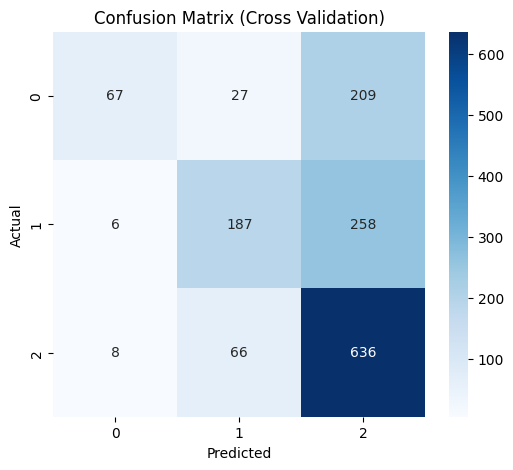

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_true, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Cross Validation)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [16]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt

In [17]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracies = []
all_preds = []
all_true = []

In [20]:
for fold, (train_idx, test_idx) in enumerate(kf.split(X_fused, y_aligned)):

    print(f"\n🔥 Fold {fold+1}")

    # Split
    X_train, X_test = X_fused[train_idx], X_fused[test_idx]
    y_train, y_test = y_aligned[train_idx], y_aligned[test_idx]

    # =========================
    # 🔥 SMOTE (ONLY ON TRAIN)
    # =========================
    smote = SMOTE(random_state=42)
    X_train, y_train = smote.fit_resample(X_train, y_train)

    print("After SMOTE:", Counter(y_train))

    # =========================
    # 🔥 CLASS WEIGHTS
    # =========================
    class_counts = Counter(y_train)
    total = sum(class_counts.values())

    weights = {cls: total/count for cls, count in class_counts.items()}
    sample_weights = np.array([weights[label] for label in y_train])

    # =========================
    # 🔥 MODEL
    # =========================
    model = XGBClassifier(
        n_estimators=1500,
        learning_rate=0.02,
        max_depth=7,
        min_child_weight=5,
        gamma=0.3,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.8,
        reg_lambda=1.8,
        objective='multi:softprob',   # 🔥 important
        num_class=len(np.unique(y_aligned)),
        tree_method='hist',
        random_state=42
    )

    model.fit(X_train, y_train, sample_weight=sample_weights)

    # =========================
    # 🔥 PREDICTION
    # =========================
    

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

    print("Accuracy:", acc)

    all_preds.extend(y_pred)
    all_true.extend(y_test)






🔥 Fold 1
After SMOTE: Counter({np.int64(1): 568, np.int64(0): 568, np.int64(2): 568})
Accuracy: 0.5972696245733788

🔥 Fold 2
After SMOTE: Counter({np.int64(1): 568, np.int64(0): 568, np.int64(2): 568})
Accuracy: 0.5870307167235495

🔥 Fold 3
After SMOTE: Counter({np.int64(1): 568, np.int64(0): 568, np.int64(2): 568})
Accuracy: 0.6348122866894198

🔥 Fold 4
After SMOTE: Counter({np.int64(1): 568, np.int64(0): 568, np.int64(2): 568})
Accuracy: 0.590443686006826

🔥 Fold 5
After SMOTE: Counter({np.int64(1): 568, np.int64(0): 568, np.int64(2): 568})
Accuracy: 0.6198630136986302


In [21]:
print("\n===== FINAL CROSS-VALIDATION RESULTS =====\n")

print("Fold Accuracies:", accuracies)
print("Mean Accuracy:", np.mean(accuracies))
print("Std Dev:", np.std(accuracies))

print("\n===== CLASSIFICATION REPORT =====\n")
print(classification_report(all_true, all_preds))


===== FINAL CROSS-VALIDATION RESULTS =====

Fold Accuracies: [0.5972696245733788, 0.5870307167235495, 0.6348122866894198, 0.590443686006826, 0.6198630136986302]
Mean Accuracy: 0.6058838655383609
Std Dev: 0.018440800661479014

===== CLASSIFICATION REPORT =====

              precision    recall  f1-score   support

           0       0.60      0.33      0.42       303
           1       0.61      0.48      0.54       451
           2       0.60      0.81      0.69       710

    accuracy                           0.61      1464
   macro avg       0.61      0.54      0.55      1464
weighted avg       0.61      0.61      0.59      1464



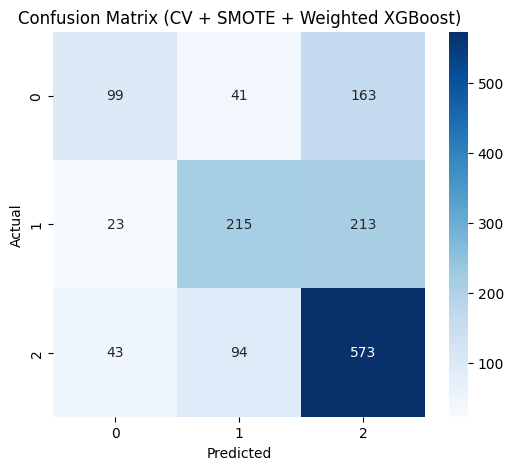

In [22]:
cm = confusion_matrix(all_true, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (CV + SMOTE + Weighted XGBoost)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [23]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt

In [24]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

all_preds = []
all_true = []
accuracies = []

In [25]:
for fold, (train_idx, test_idx) in enumerate(kf.split(X_fused, y_aligned)):

    print(f"\n🔥 Fold {fold+1}")

    X_train, X_test = X_fused[train_idx], X_fused[test_idx]
    y_train, y_test = y_aligned[train_idx], y_aligned[test_idx]

    # =========================
    # 🔥 SMOTE
    # =========================
    smote = SMOTE(random_state=42)
    X_train, y_train = smote.fit_resample(X_train, y_train)

    print("After SMOTE:", Counter(y_train))

    # =========================
    # 🔥 BASE MODELS
    # =========================
    xgb = XGBClassifier(
        n_estimators=1200,
        learning_rate=0.025,
        max_depth=6,
        subsample=0.85,
        colsample_bytree=0.85,
        objective='multi:softprob',
        num_class=len(np.unique(y_aligned)),
        tree_method='hist',
        random_state=42
    )

    rf = RandomForestClassifier(
        n_estimators=500,
        max_depth=20,
        random_state=42,
        n_jobs=-1
    )

    lgbm = LGBMClassifier(
        n_estimators=800,
        learning_rate=0.03,
        max_depth=7,
        random_state=42
    )

    # =========================
    # 🔥 TRAIN BASE MODELS
    # =========================
    xgb.fit(X_train, y_train)
    rf.fit(X_train, y_train)
    lgbm.fit(X_train, y_train)

    # =========================
    # 🔥 META FEATURES (TRAIN)
    # =========================
    train_meta = np.hstack([
        xgb.predict_proba(X_train),
        rf.predict_proba(X_train),
        lgbm.predict_proba(X_train)
    ])

    # =========================
    # 🔥 META MODEL
    # =========================
    meta_model = LogisticRegression(max_iter=1000)
    meta_model.fit(train_meta, y_train)

    # =========================
    # 🔥 META FEATURES (TEST)
    # =========================
    test_meta = np.hstack([
        xgb.predict_proba(X_test),
        rf.predict_proba(X_test),
        lgbm.predict_proba(X_test)
    ])

    # =========================
    # 🔥 FINAL PREDICTION
    # =========================
    y_pred = meta_model.predict(test_meta)

    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

    print("Accuracy:", acc)

    all_preds.extend(y_pred)
    all_true.extend(y_test)


🔥 Fold 1
After SMOTE: Counter({np.int64(1): 568, np.int64(0): 568, np.int64(2): 568})
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003724 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 76500
[LightGBM] [Info] Number of data points in the train set: 1704, number of used features: 300
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] 

d:\Anaconda\envs\py310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\Anaconda\envs\py310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy: 0.6040955631399317

🔥 Fold 2
After SMOTE: Counter({np.int64(1): 568, np.int64(0): 568, np.int64(2): 568})
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003465 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 76500
[LightGBM] [Info] Number of data points in the train set: 1704, number of used features: 300
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

d:\Anaconda\envs\py310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\Anaconda\envs\py310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy: 0.5870307167235495

🔥 Fold 3
After SMOTE: Counter({np.int64(1): 568, np.int64(0): 568, np.int64(2): 568})
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003923 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 76500
[LightGBM] [Info] Number of data points in the train set: 1704, number of used features: 300
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

d:\Anaconda\envs\py310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\Anaconda\envs\py310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy: 0.6245733788395904

🔥 Fold 4
After SMOTE: Counter({np.int64(1): 568, np.int64(0): 568, np.int64(2): 568})
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003494 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 76500
[LightGBM] [Info] Number of data points in the train set: 1704, number of used features: 300
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

d:\Anaconda\envs\py310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\Anaconda\envs\py310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy: 0.6109215017064846

🔥 Fold 5
After SMOTE: Counter({np.int64(1): 568, np.int64(0): 568, np.int64(2): 568})
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002522 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 76500
[LightGBM] [Info] Number of data points in the train set: 1704, number of used features: 300
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

d:\Anaconda\envs\py310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\Anaconda\envs\py310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [26]:
print("\n===== FINAL STACKING RESULTS =====\n")

print("Fold Accuracies:", accuracies)
print("Mean Accuracy:", np.mean(accuracies))
print("Std Dev:", np.std(accuracies))

print("\n===== CLASSIFICATION REPORT =====\n")
print(classification_report(all_true, all_preds))


===== FINAL STACKING RESULTS =====

Fold Accuracies: [0.6040955631399317, 0.5870307167235495, 0.6245733788395904, 0.6109215017064846, 0.589041095890411]
Mean Accuracy: 0.6031324512599935
Std Dev: 0.013993873074018916

===== CLASSIFICATION REPORT =====

              precision    recall  f1-score   support

           0       0.64      0.34      0.45       303
           1       0.59      0.47      0.52       451
           2       0.60      0.80      0.69       710

    accuracy                           0.60      1464
   macro avg       0.61      0.54      0.55      1464
weighted avg       0.61      0.60      0.59      1464



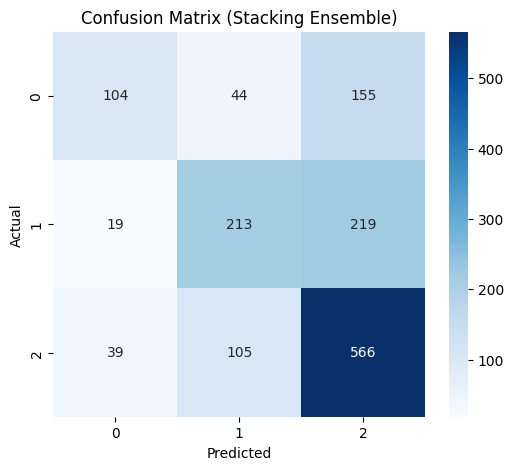

In [27]:
cm = confusion_matrix(all_true, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Stacking Ensemble)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [28]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt

In [29]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracies = []
all_preds = []
all_true = []

In [30]:
for fold, (train_idx, test_idx) in enumerate(kf.split(X_fused, y_aligned)):

    print(f"\n🔥 Fold {fold+1}")

    X_train, X_test = X_fused[train_idx], X_fused[test_idx]
    y_train, y_test = y_aligned[train_idx], y_aligned[test_idx]

    # =========================
    # 🔥 SMOTE (ONLY TRAIN)
    # =========================
    smote = SMOTE(random_state=42)
    X_train, y_train = smote.fit_resample(X_train, y_train)

    print("After SMOTE:", Counter(y_train))

    # =========================
    # 🔥 TUNED RANDOM FOREST
    # =========================
    model = RandomForestClassifier(
        n_estimators=700,
        max_depth=25,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='sqrt',
        bootstrap=True,
        class_weight='balanced',   # 🔥 important
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    # =========================
    # 🔥 PREDICTION
    # =========================
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

    print("Accuracy:", acc)

    all_preds.extend(y_pred)
    all_true.extend(y_test)


🔥 Fold 1
After SMOTE: Counter({np.int64(1): 568, np.int64(0): 568, np.int64(2): 568})
Accuracy: 0.6109215017064846

🔥 Fold 2
After SMOTE: Counter({np.int64(1): 568, np.int64(0): 568, np.int64(2): 568})
Accuracy: 0.5870307167235495

🔥 Fold 3
After SMOTE: Counter({np.int64(1): 568, np.int64(0): 568, np.int64(2): 568})
Accuracy: 0.6382252559726962

🔥 Fold 4
After SMOTE: Counter({np.int64(1): 568, np.int64(0): 568, np.int64(2): 568})
Accuracy: 0.5938566552901023

🔥 Fold 5
After SMOTE: Counter({np.int64(1): 568, np.int64(0): 568, np.int64(2): 568})
Accuracy: 0.6301369863013698


In [31]:
print("\n===== RANDOM FOREST CV RESULTS =====\n")

print("Fold Accuracies:", accuracies)
print("Mean Accuracy:", np.mean(accuracies))
print("Std Dev:", np.std(accuracies))

print("\n===== CLASSIFICATION REPORT =====\n")
print(classification_report(all_true, all_preds))


===== RANDOM FOREST CV RESULTS =====

Fold Accuracies: [0.6109215017064846, 0.5870307167235495, 0.6382252559726962, 0.5938566552901023, 0.6301369863013698]
Mean Accuracy: 0.6120342231988405
Std Dev: 0.019852041154318312

===== CLASSIFICATION REPORT =====

              precision    recall  f1-score   support

           0       0.83      0.25      0.38       303
           1       0.71      0.36      0.48       451
           2       0.58      0.93      0.71       710

    accuracy                           0.61      1464
   macro avg       0.70      0.51      0.52      1464
weighted avg       0.67      0.61      0.57      1464



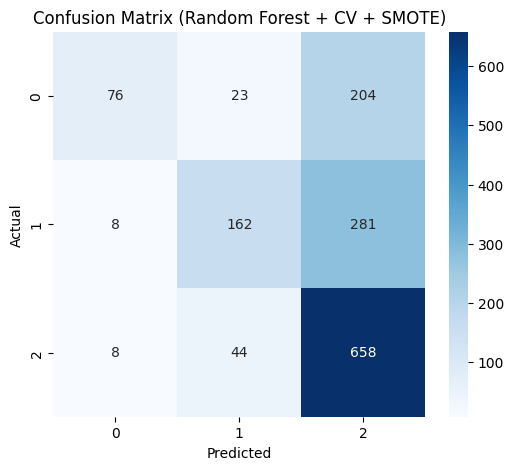

In [32]:
cm = confusion_matrix(all_true, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Random Forest + CV + SMOTE)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [33]:
import numpy as np

X_img = np.load("mri_embeddings.npy")
y = np.load("labels.npy")
img_ids = np.load("img_ids.npy")

print("MRI shape:", X_img.shape)

MRI shape: (2294, 3072)


In [34]:
import pandas as pd

bert_df = pd.read_csv(r"D:\ADNI_BERT_embeddings_512.csv")

print("BERT shape:", bert_df.shape)
print(bert_df.head())

BERT shape: (1464, 516)
  Image Data ID   RID        PTID Group    bert_0    bert_1    bert_2  \
0       I112538  1311  941_S_1311   MCI  0.046520 -0.004498 -0.006471   
1        I97341  1311  941_S_1311   MCI  0.048760 -0.003118 -0.015076   
2        I75150  1202  941_S_1202    CN  0.047486 -0.001996 -0.000542   
3       I105437  1202  941_S_1202    CN  0.041326 -0.001045 -0.000135   
4       I108336  1197  941_S_1197    CN  0.050408 -0.005467 -0.003023   

     bert_3    bert_4    bert_5  ...  bert_502  bert_503  bert_504  bert_505  \
0  0.088032 -0.002303  0.052479  ... -0.063068  0.079297 -0.069202 -0.054640   
1  0.088674 -0.002863  0.054960  ... -0.063133  0.081417 -0.064229 -0.055444   
2  0.091288 -0.003527  0.051281  ... -0.068264  0.072590 -0.066312 -0.060175   
3  0.094208 -0.003518  0.050177  ... -0.066339  0.071323 -0.070200 -0.061857   
4  0.090593 -0.003267  0.053620  ... -0.068517  0.071746 -0.069509 -0.056355   

   bert_506  bert_507  bert_508  bert_509  bert_510  ber

In [37]:
import pandas as pd
import numpy as np

# BERT embeddings
df_bert = pd.read_csv(r"D:\ADNI_BERT_embeddings_512.csv")

# MRI embeddings
df_mri = np.load(r"mri_embeddings.npy")

In [39]:
df_bert = df_bert.rename(columns={"Image Data ID": "ID"})
df_mri = pd.DataFrame(df_mri)
df_mri = df_mri.rename(columns={"Image Data ID": "ID"})

In [1]:
import pandas as pd
import numpy as np

# BERT embeddings
bert_df = pd.read_csv(r"D:\ADNI_BERT_embeddings_512.csv")

# Labels file
labels_df = pd.read_csv(r"D:\ADNI_paths_labels.csv")

labels_df = labels_df[['filepath', 'label']].dropna()

In [2]:
import os

def extract_img_id(path):
    filename = os.path.basename(path)
    filename = filename.replace(".nii", "").replace(".gz", "")
    return filename.split("_")[-1]

labels_df["Image Data ID"] = labels_df["filepath"].apply(extract_img_id)

In [3]:
# Clean IDs
bert_df["Image Data ID"] = bert_df["Image Data ID"].astype(str).str.strip()
labels_df["Image Data ID"] = labels_df["Image Data ID"].astype(str).str.strip()

# Merge
df = pd.merge(bert_df, labels_df[['Image Data ID', 'label']], on="Image Data ID")

print("Merged shape:", df.shape)

Merged shape: (1464, 517)


In [4]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["label_id"] = le.fit_transform(df["label"])

In [5]:
X = df.drop(columns=["Image Data ID", "label", "label_id"]).values
y = df["label_id"].values

print("Feature shape:", X.shape)

Feature shape: (1464, 515)


In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

ValueError: could not convert string to float: '941_S_1311'

In [7]:
print(df.columns)

Index(['Image Data ID', 'RID', 'PTID', 'Group', 'bert_0', 'bert_1', 'bert_2',
       'bert_3', 'bert_4', 'bert_5',
       ...
       'bert_504', 'bert_505', 'bert_506', 'bert_507', 'bert_508', 'bert_509',
       'bert_510', 'bert_511', 'label', 'label_id'],
      dtype='object', length=518)


In [8]:
X = df.select_dtypes(include=[np.number]).values
y = df["label_id"].values

print("Fixed shape:", X.shape)

Fixed shape: (1464, 514)


In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [10]:
print(type(X))
print(X.dtype)

<class 'numpy.ndarray'>
float64


In [11]:
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from collections import Counter

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

all_preds = []
all_true = []

for fold, (train_idx, test_idx) in enumerate(kf.split(X, y)):

    print(f"\n🔥 Fold {fold+1}")

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # SMOTE
    smote = SMOTE(random_state=42)
    X_train, y_train = smote.fit_resample(X_train, y_train)

    print("After SMOTE:", Counter(y_train))

    model = RandomForestClassifier(
        n_estimators=600,
        max_depth=20,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    all_preds.extend(y_pred)
    all_true.extend(y_test)


🔥 Fold 1
After SMOTE: Counter({np.int64(2): 568, np.int64(1): 568, np.int64(0): 568})

🔥 Fold 2
After SMOTE: Counter({np.int64(2): 568, np.int64(1): 568, np.int64(0): 568})

🔥 Fold 3
After SMOTE: Counter({np.int64(2): 568, np.int64(1): 568, np.int64(0): 568})

🔥 Fold 4
After SMOTE: Counter({np.int64(2): 568, np.int64(1): 568, np.int64(0): 568})

🔥 Fold 5
After SMOTE: Counter({np.int64(2): 568, np.int64(1): 568, np.int64(0): 568})


In [12]:
from sklearn.metrics import classification_report

print("\n===== BERT ONLY RESULTS =====\n")
print(classification_report(all_true, all_preds, target_names=le.classes_))


===== BERT ONLY RESULTS =====

              precision    recall  f1-score   support

          AD       0.92      0.79      0.85       303
          CN       0.84      0.80      0.82       451
         MCI       0.88      0.95      0.91       710

    accuracy                           0.87      1464
   macro avg       0.88      0.85      0.86      1464
weighted avg       0.87      0.87      0.87      1464



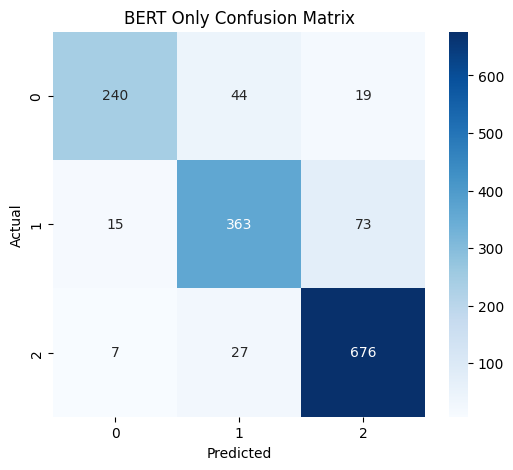

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_true, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("BERT Only Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()